# Bayesian modelling of chocolate quality rating
#### Authors: Julia Wiktorowicz, Patrycja Wybranowska

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from cmdstanpy import CmdStanModel
import arviz as az
import matplotlib
import matplotlib.colors as mcolors

RELATIVE = True


## Data preprocessing
The raw data from Flavors of Cacao database contains information about producer and its origin country, country and details of bean origin, basic ingredients, most memorable characteristics, final rating and date of the review.



In [2]:
columns = [
    'REF', 'Company', 'Company Location', 'Review Date', 
    'Country of Bean Origin', 'Specific Bean Origin', 
    'Cocoa Percent', 'Ingredients', 'Most Memorable Characteristics', 'Rating'
]

df_pre = pd.read_csv('data/data.txt', sep='\t', names=columns, skiprows=1) if RELATIVE else pd.read_csv('/workspace/project2/Chocolate-DA/data/data.txt', sep='\t', names=columns, skiprows=1)
df_pre.head()

,REF,Company,Company Location,Review Date,Country of Bean Origin,Specific Bean Origin,Cocoa Percent,Ingredients,Most Memorable Characteristics,Rating
0,3016,Cacao Store,Japan,2026,Thailand,Chumphon,70%,"3- B,S,C","light apricot, pear, nutty, clean",3.25
1,3016,Cacao Store,Japan,2026,Taiwan,Fu-Wan,70%,"3- B,S,C","cocoa,roasty,pungent, chemical",2.75
2,3016,Cacao Store,Japan,2026,Madagascar,Ambanja,75%,"3- B,S,C","high acid, atypical honey",3.00
3,3016,URA,Peru,2026,Peru,"Piura, Chulucanas, Finca Tito Jimenez",70%,"3- B,S,C","grapes, roast (smoke like)",3.75
4,3020,URA,Peru,2026,Peru,"VRAEM 99, Pichari, Cusco, Finca Daria",70%,"3- B,S,C",plum,3.50


In [3]:
df = pd.read_csv('data/chocolate_data_preprocessed.csv') if RELATIVE else pd.read_csv('/workspace/project2/Chocolate-DA/data/chocolate_data_preprocessed.csv')

observed_ratings = sorted(df['Rating'].unique())     # only values that actually occur
rating_map = {val: i + 1 for i, val in enumerate(observed_ratings)}
inv_rating_map = {v: k for k, v in rating_map.items()}   # build this here, right next to rating_map

df['rating_id'] = df['Rating'].map(rating_map)
C = len(observed_ratings)
J = df['Bean Origin ID'].max()
K = df['Company Location ID'].max()


print(f"C = {C}")
print(df['rating_id'].value_counts().sort_index())
print(f"NaNs in rating_id: {df['rating_id'].isna().sum()}")  # should be 0
df.head()

# for each bean origin, find the most common producer location
origin_to_loc = (
    df.groupby('Bean Origin ID')['Company Location ID']
    .agg(lambda x: x.mode()[0])
    .to_dict()
)
# list of length J: for origin j, which producer location is it primarily from
origin_location = [int(origin_to_loc[j]) for j in range(1, J + 1)]

C = 8
rating_id
1      3
2     54
3    113
4    248
5    223
6    276
7    118
8     41
Name: count, dtype: int64
NaNs in rating_id: 0


# Model 1

This model establishes the baseline geographic effects, mapping the causal pathway where the producer location determines both the direct manufacturing quality and the typical quality of the beans they source.

## 1. Mathematical Formulation

The data generating process assumes the ordinal rating for observation $i$ is driven by a continuous latent variable $\phi_i$, bounded by a set of ordered cutpoints $c$.

### Likelihood

$$
y_i \sim \text{OrderedLogistic}(\phi_i, c)
$$

### Linear Predictor

$$
\phi_i = \mu + \alpha_{j[i]} + \gamma_{k[i]}
$$

where $j[i]$ is the bean origin for observation $i$, and $k[i]$ is the producer location for observation $i$.

### Hierarchical Structure

To account for the causal nesting (Producer Location $\rightarrow$ Bean Origin), the model uses varying intercepts. For computational efficiency and to avoid divergent transitions, these are parameterized using a non-centered formulation:

$$
\gamma_k \sim \text{Normal}(0, \sigma_{\text{producer}})
$$

$$
\lambda_k \sim \text{Normal}(0, \sigma_{\lambda})
$$

$$
\alpha_j \sim \text{Normal}(\lambda_{k[j]}, \sigma_{\text{origin}})
$$

$\lambda_k$ represents the expected baseline quality of beans sourced by producer location $k$, while $\alpha_j$ is the specific residual quality of origin $j$.


## 2. Priors

### Prior for the Cutpoints

$$
c \sim \text{Normal}(0, 2.5)
$$

This is a standard, weakly informative prior for ordinal cutpoints on the logit scale. It allows the cutpoints to spread out enough to cover the categories without assigning unrealistic probabilities to extreme log-odds shifts.

### Prior for the Global Mean

$$
\mu \sim \text{Normal}(0, 1)
$$

On the log-odds scale, a shift of 1 is substantial (multiplying the odds by approximately $2.72$). A standard normal prior keeps the global mean centered, expecting most baseline ratings to fall near the middle categories.

### Priors for the Hierarchical Scale Parameters

$$
\sigma_{\text{producer}}, \sigma_{\lambda}, \sigma_{\text{origin}} \sim \text{HalfNormal}(0, 1)
$$

These scale parameters dictate the variance between countries and origins. A half-normal prior with a standard deviation of 1 allows for meaningful variation between groups while preventing the model from predicting impossible extremes (e.g., a single country having an infinite baseline advantage).

### Priors for the Non-Centered Parameters

$$
\gamma_{\text{raw}}, \lambda_{\text{raw}}, \alpha_{\text{raw}} \sim \text{Normal}(0, 1)
$$

Requirement for the non-centered parameterization so the HMC sampler can explore it efficiently without hitting the funnel shape geometry.

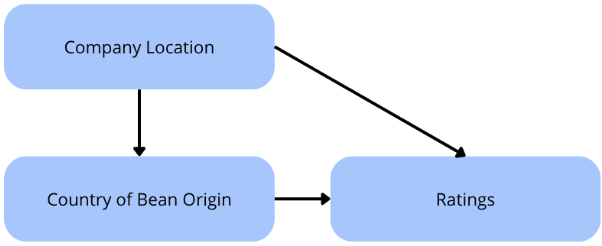

### Prior predictive check

In [4]:
prior_model1 = CmdStanModel(stan_file="prior_model1.stan") if RELATIVE else CmdStanModel(stan_file="/workspace/project2/Chocolate-DA/prior_model1.stan")

J = df['Bean Origin ID'].max()
K = df['Company Location ID'].max()

prior_data1 = {
    "N": len(df),
    "J": J,
    "K": K,
    "C": C,
    "origin":          df['Bean Origin ID'].tolist(),
    "producer":        df['Company Location ID'].tolist(),
    "origin_location": origin_location,    # ← new, must be computed before this cell
}


prior_fit1 = prior_model1.sample(
    data=prior_data1,
    fixed_param=True,
    iter_sampling=2000,
    chains=1,
    seed=42,
    show_progress=False,
)



# pull everything including the new parameters
rating_pred_prior1   = prior_fit1.stan_variable("rating_pred")
a_prior_draws1       = prior_fit1.stan_variable("alpha")
b_prior_draws1       = prior_fit1.stan_variable("gamma")
mu_global_prior1     = prior_fit1.stan_variable("mu_global")     # ← was missing
sigma_origin_prior1  = prior_fit1.stan_variable("sigma_origin")
sigma_prod_prior1    = prior_fit1.stan_variable("sigma_producer")
sigma_lam_prior1     = prior_fit1.stan_variable("sigma_lambda")  # ← was missing
alpha_prior1         = prior_fit1.stan_variable("alpha")
gamma_prior1         = prior_fit1.stan_variable("gamma")         # ← was missing
c_prior_draws        = prior_fit1.stan_variable("c")

10:43:08 - cmdstanpy - INFO - CmdStan start processing
10:43:08 - cmdstanpy - INFO - Chain [1] start processing
10:43:11 - cmdstanpy - INFO - Chain [1] done processing


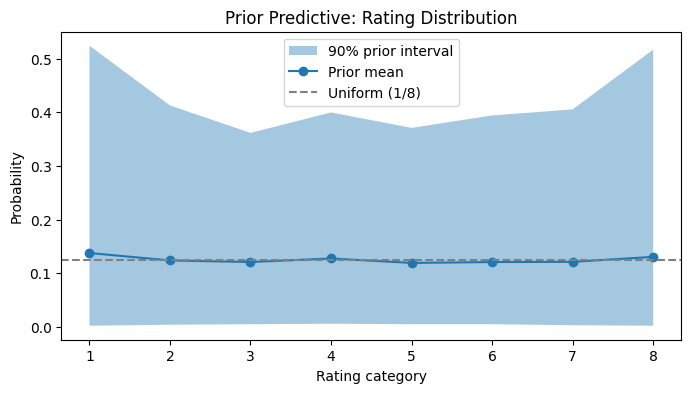

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
# rating_pred shape: (n_draws, N) — average over observations
pred_counts = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C), 1, rating_pred_prior1
)
pred_probs = pred_counts / pred_counts.sum(axis=1, keepdims=True)

ax.fill_between(
    range(1, C+1),
    np.percentile(pred_probs, 5, axis=0),
    np.percentile(pred_probs, 95, axis=0),
    alpha=0.4, label="90% prior interval"
)
ax.plot(range(1, C+1), pred_probs.mean(axis=0), marker='o', label="Prior mean")
ax.axhline(1/C, ls='--', color='gray', label=f"Uniform (1/{C})")
ax.set_xlabel("Rating category"); ax.set_ylabel("Probability")
ax.set_title("Prior Predictive: Rating Distribution")
ax.legend()

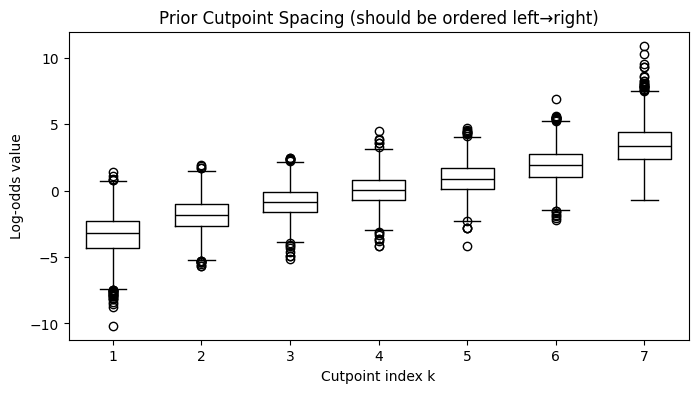

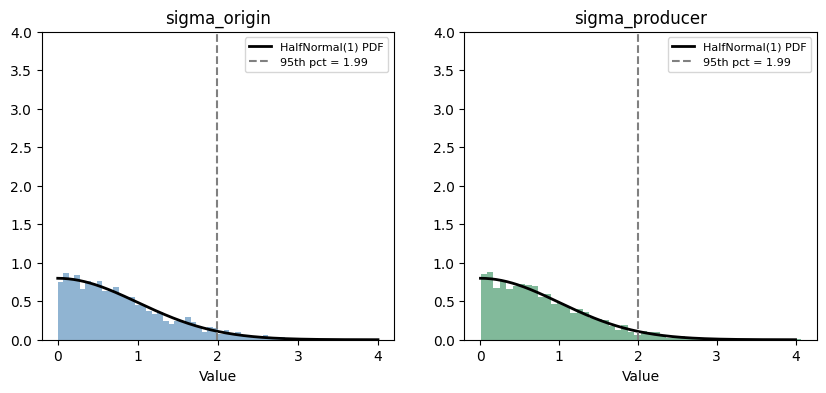

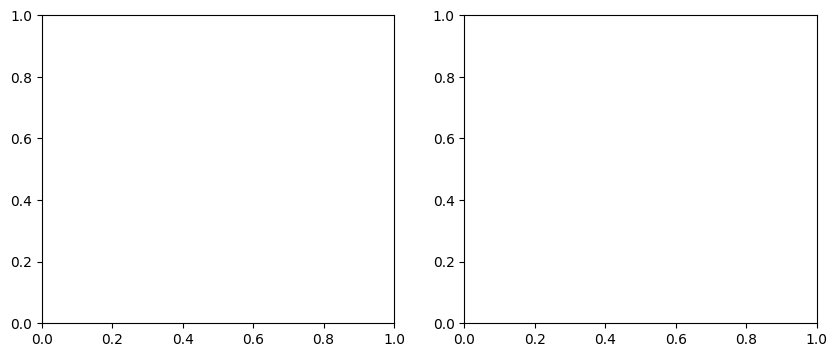

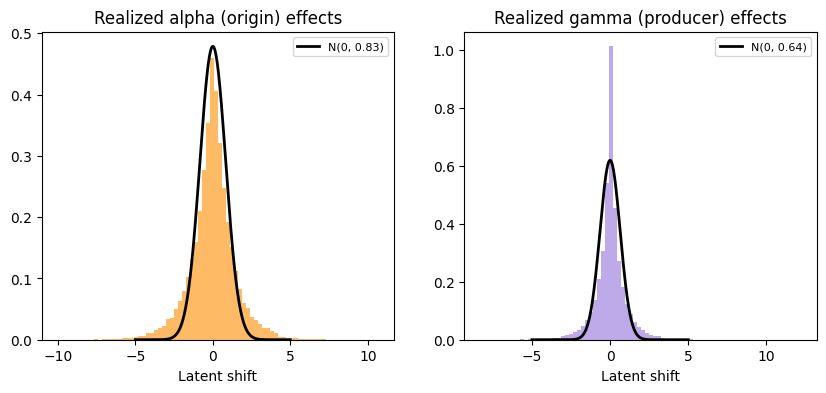

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
for k in range(C - 1):
    ax.boxplot(c_prior_draws[:, k], positions=[k+1], widths=0.6,
               medianprops=dict(color='black'))
ax.set_xlabel("Cutpoint index k")
ax.set_ylabel("Log-odds value")
ax.set_title("Prior Cutpoint Spacing (should be ordered left→right)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.linspace(0, 4, 300)
ref = stats.halfnorm.pdf(x, scale=1.0)

for ax, samples, name, color in zip(
    axes,
    [sigma_origin_prior1, sigma_prod_prior1],
    ["sigma_origin", "sigma_producer"],
    ["steelblue", "seagreen"]
):
    ax.hist(samples, bins=50, density=True, alpha=0.6, color=color)
    ax.plot(x, ref, 'k-', lw=2, label="HalfNormal(1) PDF")
    ax.axvline(np.percentile(samples, 95), ls='--', color='gray',
               label=f"95th pct = {np.percentile(samples,95):.2f}")
    ax.set_title(f"{name}")
    ax.set_xlabel("Value"); ax.legend(fontsize=8)
    ax.set_ylim([0, 4])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, draws, name, color in zip(
    axes, [a_prior_draws1, b_prior_draws1],
    ["alpha (origin)", "gamma (producer)"], ["darkorange", "mediumpurple"]
):
    ax.hist(draws.flatten(), bins=80, density=True, alpha=0.6, color=color)
    # overlay a N(0, median_sigma) reference
    med_sigma = np.median(draws.std(axis=1))
    x = np.linspace(-5, 5, 300)
    
    ax.plot(x, stats.norm.pdf(x, 0, med_sigma), 'k-', lw=2,
            label=f"N(0, {med_sigma:.2f})")
    ax.set_title(f"Realized {name} effects")
    ax.set_xlabel("Latent shift"); ax.legend(fontsize=8)

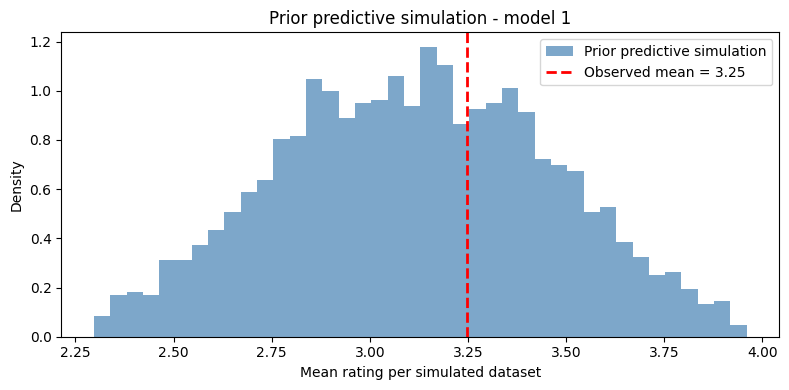

In [7]:
id_to_rating = np.vectorize(inv_rating_map.get)
rating_pred_values = id_to_rating(rating_pred_prior1)

prior_draw_means1 = rating_pred_values.mean(axis=1)
observed_mean = df["Rating"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_draw_means1, bins=40, density=True, alpha=0.7,
        color="steelblue", label="Prior predictive simulation")
ax.axvline(observed_mean, color="red", lw=2, ls="--",
           label=f"Observed mean = {observed_mean:.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Prior predictive simulation - model 1")
ax.legend()
plt.tight_layout()
plt.show()

## posterior model 1

10:43:19 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

10:44:24 - cmdstanpy - INFO - CmdStan done processing.
10:44:24 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -504.891, but should be greater than the previous element, -504.891 (in 'model_1.stan', line 64, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -505.672, but should be greater than the previous element, -505.672 (in 'model_1.stan', line 64, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -125.61, but should be greater than the previous element, -125.61 (in 'model_1.stan', line 64, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -29.9186, but should be greater than the previous element, -29.9186 (in 'model_1.stan', line 64, column 2 to column 36)
	Exception: ordered_logistic: Loca


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


Parameters with R-hat > 1.01: 0

Parameters with ESS < 400: 0


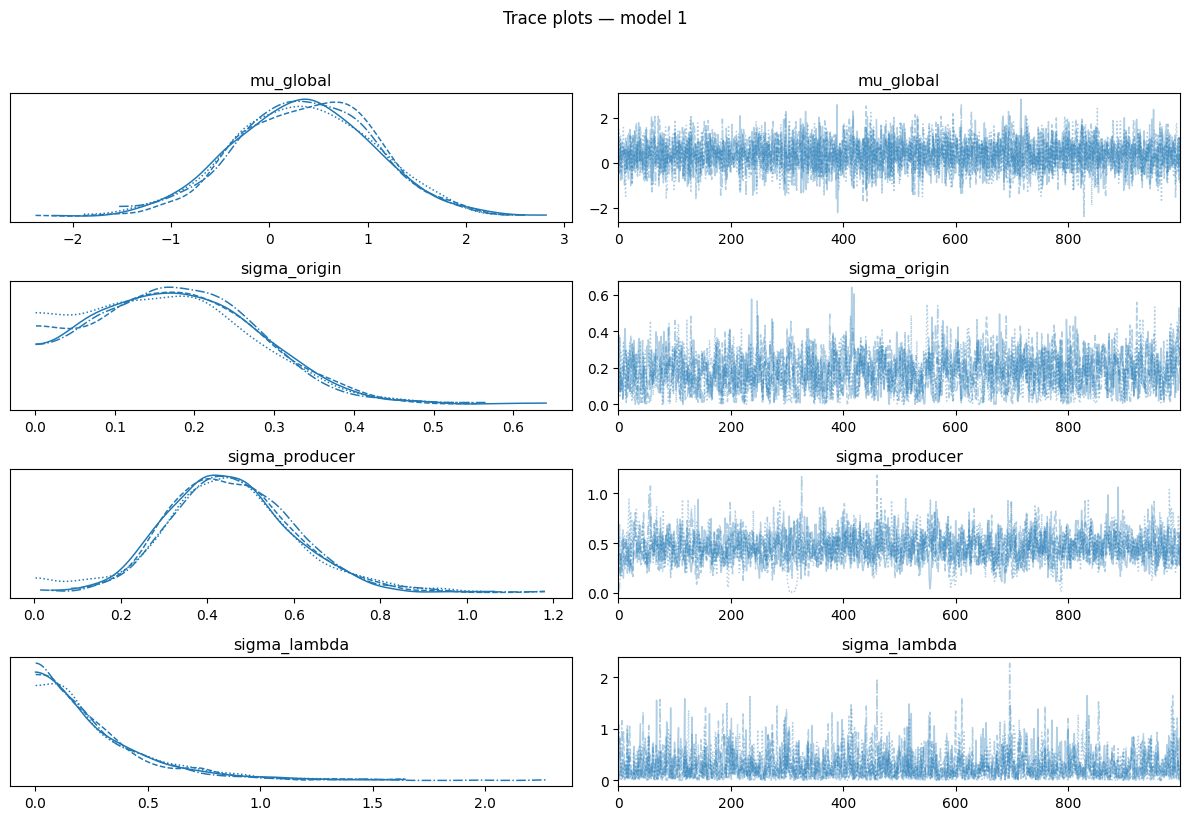

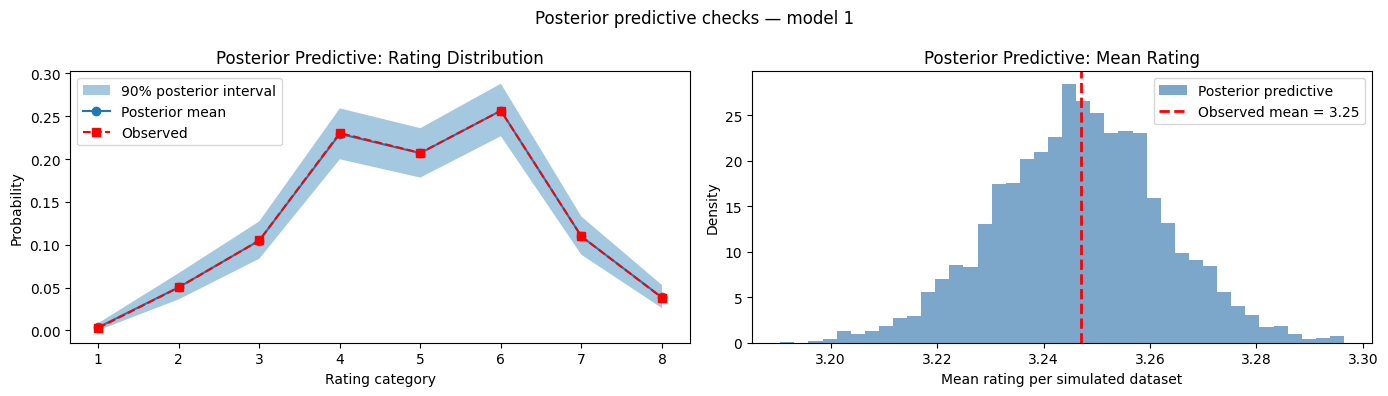

In [8]:
# ── Fit ───────────────────────────────────────────────────────────────────────
model_1_fit = CmdStanModel(stan_file="model_1.stan")

data_sim1 = {
    "N": len(df),
    "J": J,
    "K": K,
    "C": C,
    "origin":          df['Bean Origin ID'].tolist(),
    "producer":        df['Company Location ID'].tolist(),
    "rating":          df['rating_id'].tolist(),
    "origin_location": origin_location,
}

fit1 = model_1_fit.sample(
    data=data_sim1,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_progress=True,   # keep on so you can see if chains get stuck
)

# ── Pull posterior samples ─────────────────────────────────────────────────────
# pull posterior samples
# pull posterior samples
rating_pred_post1  = fit1.stan_variable("rating_pred")
alpha_samples1     = fit1.stan_variable("alpha")
gamma_samples1     = fit1.stan_variable("gamma")
lambda_samples1    = fit1.stan_variable("lambda")
sigma_origin1      = fit1.stan_variable("sigma_origin")
sigma_producer1    = fit1.stan_variable("sigma_producer")
sigma_lambda1      = fit1.stan_variable("sigma_lambda")
mu_global_samples1 = fit1.stan_variable("mu_global")
c_samples1         = fit1.stan_variable("c")

# ← this line was missing — map category ids (1–8) back to real rating values
id_to_rating     = np.vectorize(inv_rating_map.get)
rating_pred_vals = id_to_rating(rating_pred_post1)   # (draws, N), values like 2.75, 3.0 etc.

# ← this line was missing — map category ids (1–8) back to real rating values
id_to_rating     = np.vectorize(inv_rating_map.get)
rating_pred_vals = id_to_rating(rating_pred_post1)   # (draws, N), values like 2.75, 3.0 etc.

# ── Convergence diagnostics ───────────────────────────────────────────────────
print(fit1.diagnose())   # divergences, treedepth, E-BFMI — read this carefully

idata1 = az.from_cmdstanpy(fit1)   # convert once, reuse below

summary1 = az.summary(idata1)
bad_rhat = summary1[summary1['r_hat'] > 1.01]
bad_ess  = summary1[summary1['ess_bulk'] < 400]

print(f"\nParameters with R-hat > 1.01: {len(bad_rhat)}")
if len(bad_rhat) > 0:
    print(bad_rhat[['mean','sd','r_hat','ess_bulk']].head(20))

print(f"\nParameters with ESS < 400: {len(bad_ess)}")
if len(bad_ess) > 0:
    print(bad_ess[['mean','sd','r_hat','ess_bulk']].head(20))

# ── Trace plots for global params (visual convergence check) ──────────────────
az.plot_trace(idata1, var_names=["mu_global", "sigma_origin",
                                  "sigma_producer", "sigma_lambda"])
plt.suptitle("Trace plots — model 1", y=1.02)
plt.tight_layout()
plt.show()

# ── Posterior predictive check ────────────────────────────────────────────────
# map predicted category ids back to real rating values
id_to_rating    = np.vectorize(inv_rating_map.get)
pred_values     = id_to_rating(rating_pred_post1)          # (draws, N)

pred_counts = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C),
    1, rating_pred_post1
)
pred_probs = pred_counts / pred_counts.sum(axis=1, keepdims=True)

# observed distribution
obs_counts = np.bincount(df['rating_id'].values.astype(int) - 1, minlength=C)
obs_probs  = obs_counts / obs_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left: category-level posterior predictive vs observed
ax = axes[0]
ax.fill_between(
    range(1, C + 1),
    np.percentile(pred_probs, 5,  axis=0),
    np.percentile(pred_probs, 95, axis=0),
    alpha=0.4, label="90% posterior interval"
)
ax.plot(range(1, C + 1), pred_probs.mean(axis=0),
        marker='o', label="Posterior mean")
ax.plot(range(1, C + 1), obs_probs,
        marker='s', color='red', ls='--', label="Observed")
ax.set_xlabel("Rating category")
ax.set_ylabel("Probability")
ax.set_title("Posterior Predictive: Rating Distribution")
ax.legend()

# right: simulated vs observed mean rating
ax = axes[1]
post_means   = pred_values.mean(axis=1)
observed_mean = df["Rating"].mean()
ax.hist(post_means, bins=40, density=True, alpha=0.7,
        color="steelblue", label="Posterior predictive")
ax.axvline(observed_mean, color="red", lw=2, ls="--",
           label=f"Observed mean = {observed_mean:.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Posterior Predictive: Mean Rating")
ax.legend()

plt.suptitle("Posterior predictive checks — model 1")
plt.tight_layout()
plt.show()

Non-fatal warnings occured at the start of the warmup phase but they did not affect the validity of the final posterior draws. The MCMC sampling process was completed successfully with no problems detected. The R_hat values for all parameters are smaller than 1.01 indicating optimal chain convergence. 

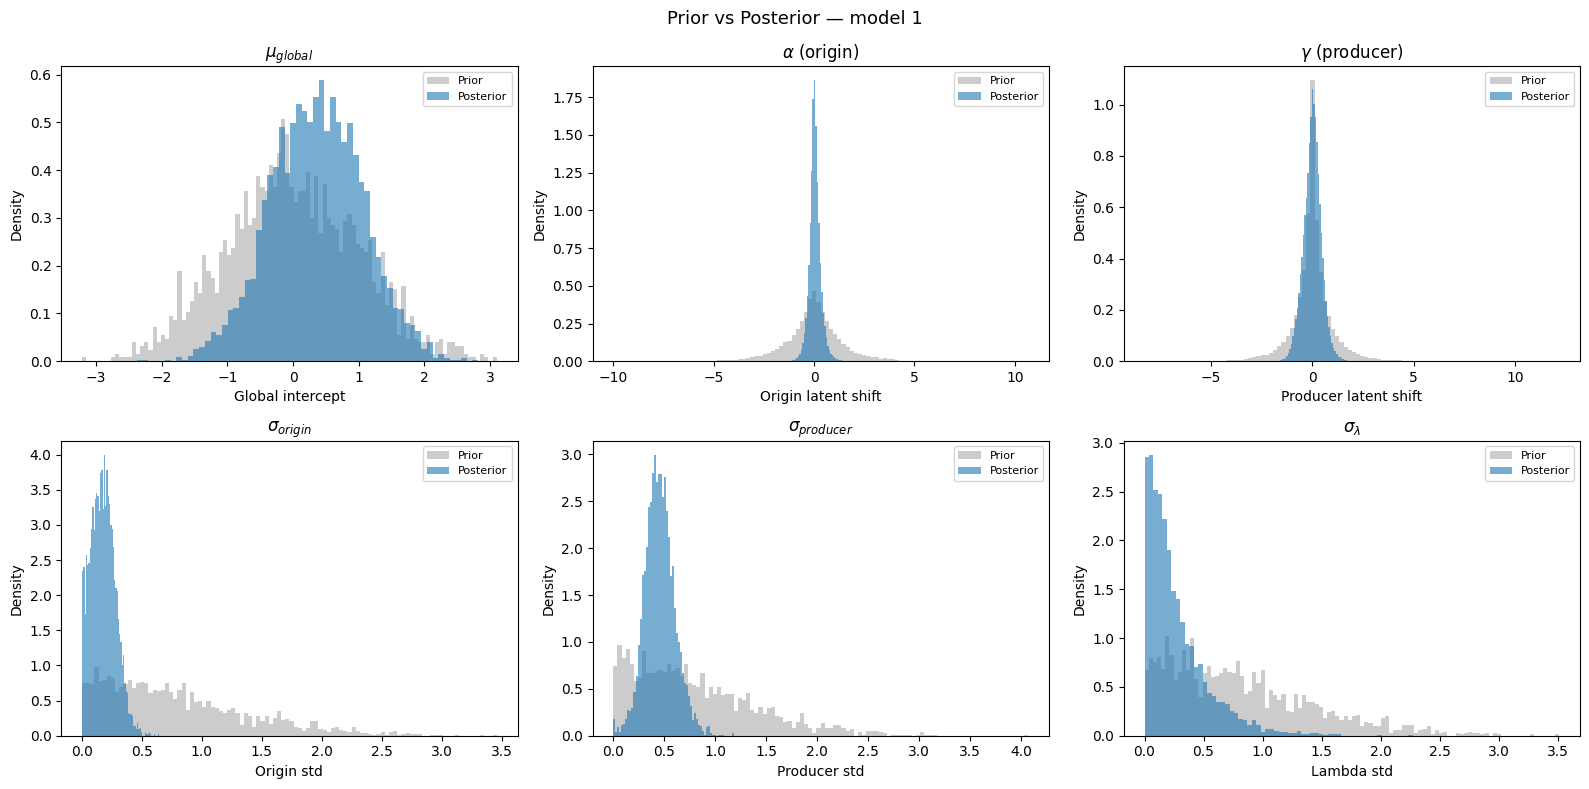

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

panels = [
    (mu_global_samples1,       mu_global_prior1,        r"$\mu_{global}$",        "Global intercept"),
    (alpha_samples1.flatten(), alpha_prior1.flatten(),   r"$\alpha$ (origin)",     "Origin latent shift"),
    (gamma_samples1.flatten(), gamma_prior1.flatten(),   r"$\gamma$ (producer)",   "Producer latent shift"),
    (sigma_origin1,            sigma_origin_prior1,      r"$\sigma_{origin}$",     "Origin std"),
    (sigma_producer1,          sigma_prod_prior1,        r"$\sigma_{producer}$",   "Producer std"),
    (sigma_lambda1,            sigma_lam_prior1,         r"$\sigma_{\lambda}$",    "Lambda std"),
]

for ax, (post, prior, title, xlabel) in zip(axes, panels):
    ax.hist(prior, bins=100, density=True, alpha=0.4, color="gray", label="Prior")
    ax.hist(post,  bins=60,  density=True, alpha=0.6, label="Posterior")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Prior vs Posterior — model 1", fontsize=13)
plt.tight_layout()
plt.show()

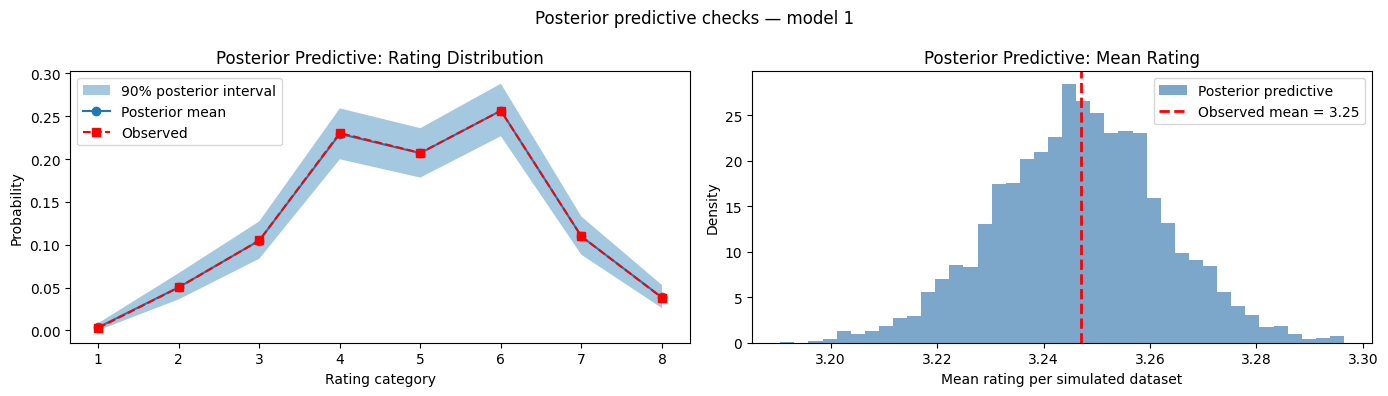

In [10]:
pred_counts = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C), 1, rating_pred_post1
)
pred_probs = pred_counts / pred_counts.sum(axis=1, keepdims=True)
obs_counts = np.bincount(df['rating_id'].values.astype(int) - 1, minlength=C)
obs_probs  = obs_counts / obs_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.fill_between(
    range(1, C + 1),
    np.percentile(pred_probs, 5,  axis=0),
    np.percentile(pred_probs, 95, axis=0),
    alpha=0.4, label="90% posterior interval"
)
ax.plot(range(1, C + 1), pred_probs.mean(axis=0), marker='o', label="Posterior mean")
ax.plot(range(1, C + 1), obs_probs, marker='s',
        color='red', ls='--', label="Observed")
ax.set_xlabel("Rating category")
ax.set_ylabel("Probability")
ax.set_title("Posterior Predictive: Rating Distribution")
ax.legend()

ax = axes[1]
ax.hist(rating_pred_vals.mean(axis=1), bins=40, density=True, alpha=0.7,
        color="steelblue", label="Posterior predictive")
ax.axvline(df["Rating"].mean(), color="red", lw=2, ls="--",
           label=f"Observed mean = {df['Rating'].mean():.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Posterior Predictive: Mean Rating")
ax.legend()

plt.suptitle("Posterior predictive checks — model 1")
plt.tight_layout()
plt.show()

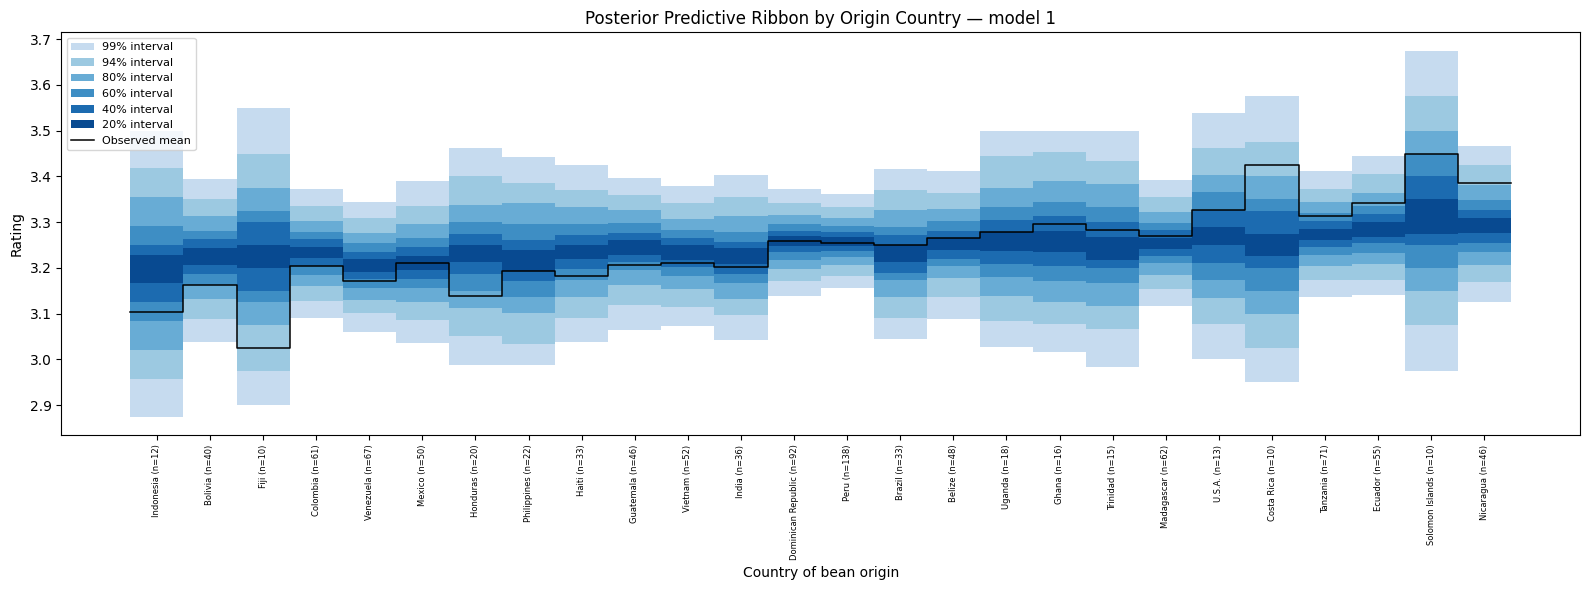

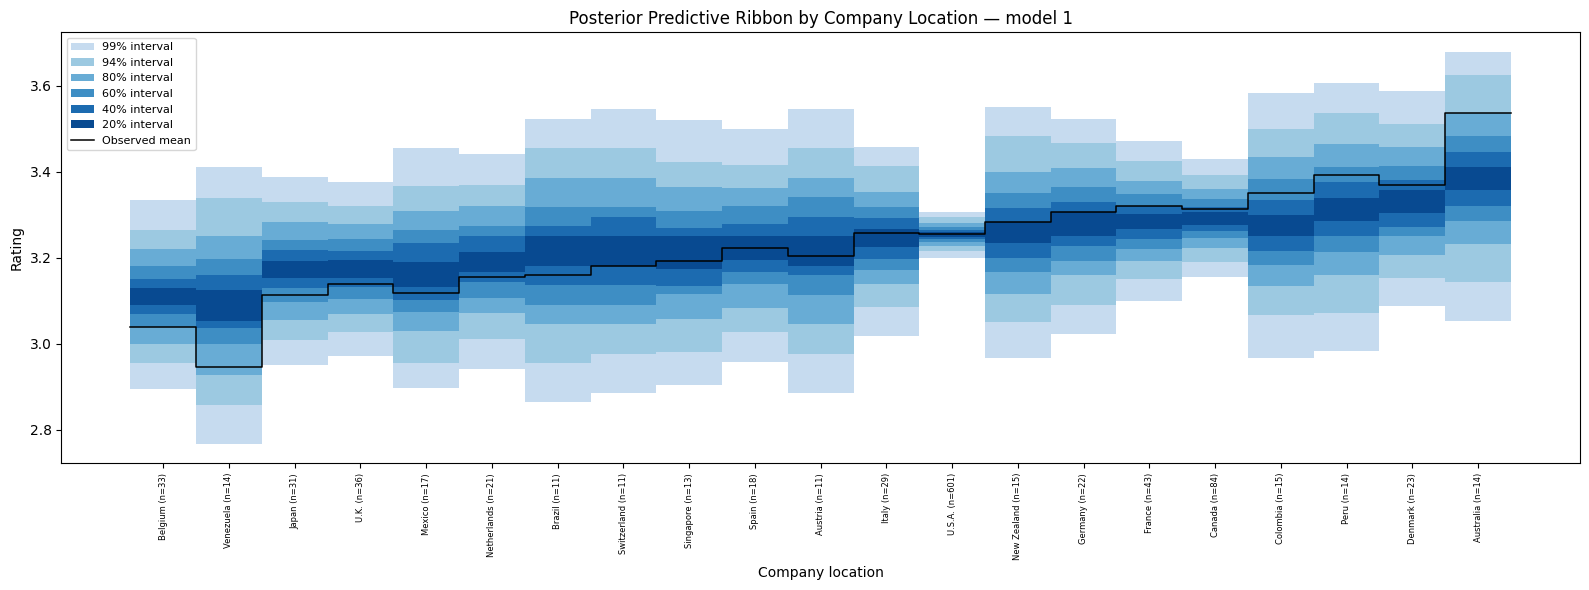

In [11]:
# ── 3. Ribbon plot by bean origin country ─────────────────────────────────────
# latent score for each origin = global mean + origin effect
mu_origin_total1 = mu_global_samples1[:, None] + alpha_samples1  # (draws, J)

current_df = df.copy().reset_index(drop=True)
countries   = sorted(current_df["Country of Bean Origin"].unique())
country_idx = {c: i + 1 for i, c in enumerate(countries)}
current_df["country_id"] = current_df["Country of Bean Origin"].map(country_idx)
counts_origin = current_df["Country of Bean Origin"].value_counts().to_dict()

results11 = pd.DataFrame({
    "country":     countries,
    "mu_mean":     mu_origin_total1.mean(axis=0),
    "mu_lower_94": np.percentile(mu_origin_total1, 3,  axis=0),
    "mu_upper_94": np.percentile(mu_origin_total1, 97, axis=0),
    "n_bars":      [counts_origin.get(c, 0) for c in countries],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

observed_per_country1 = current_df.groupby("country_id")["Rating"].mean()
obs_sorted_origin = results11["country"].map(
    lambda c: observed_per_country1[country_idx[c]]
).values

J_sorted1 = len(results11)
x2        = np.arange(1, J_sorted1 + 1)
num_draws = rating_pred_vals.shape[0]

post_pred_means_origin = np.zeros((num_draws, J_sorted1))
for i, country_name in enumerate(results11["country"]):
    idx = current_df[current_df["Country of Bean Origin"] == country_name].index.values
    post_pred_means_origin[:, i] = rating_pred_vals[:, idx].mean(axis=1)

def step_edges(values, x):
    edges   = np.concatenate([x - 0.5, x[-1:] + 0.5])
    stepped = np.concatenate([[values[0]], values])
    return edges, stepped

levels = [99, 94, 80, 60, 40, 20]
cmap   = matplotlib.colormaps["Blues"]
colors = [mcolors.to_hex(cmap(f)) for f in np.linspace(0.25, 0.9, len(levels))]

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo = np.percentile(post_pred_means_origin, (100 - lev) / 2,       axis=0)
    hi = np.percentile(post_pred_means_origin, 100 - (100 - lev) / 2, axis=0)
    e, ls = step_edges(lo, x2); _, hs = step_edges(hi, x2)
    ax.fill_between(e, ls, hs, step="pre", color=color,
                    linewidth=0, label=f"{lev}% interval")

e, os = step_edges(obs_sorted_origin, x2)
ax.step(e, os, where="pre", color="black", linewidth=1.1, label="Observed mean")
ax.set_xticks(x2)
ax.set_xticklabels(
    [f"{r['country']} (n={r['n_bars']})" for _, r in results11.iterrows()],
    rotation=90, fontsize=6
)
ax.set_xlabel("Country of bean origin"); ax.set_ylabel("Rating")
ax.set_title("Posterior Predictive Ribbon by Origin Country — model 1")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# ── 4. Ribbon plot by company (producer) location ─────────────────────────────
mu_company_total1 = mu_global_samples1[:, None] + gamma_samples1   # (draws, K)

company_locations = sorted(current_df["Company Location"].unique())
company_idx       = {c: i + 1 for i, c in enumerate(company_locations)}
current_df["company_id"] = current_df["Company Location"].map(company_idx)
counts_company = current_df["Company Location"].value_counts().to_dict()

results12 = pd.DataFrame({
    "company":     company_locations,
    "mu_mean":     mu_company_total1.mean(axis=0),
    "mu_lower_94": np.percentile(mu_company_total1, 3,  axis=0),
    "mu_upper_94": np.percentile(mu_company_total1, 97, axis=0),
    "n_bars":      [counts_company.get(c, 0) for c in company_locations],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

observed_per_company1 = current_df.groupby("company_id")["Rating"].mean()
obs_sorted_company = results12["company"].map(
    lambda c: observed_per_company1[company_idx[c]]
).values

K_sorted = len(results12)
x3       = np.arange(1, K_sorted + 1)

post_pred_means_company = np.zeros((num_draws, K_sorted))
for i, comp_name in enumerate(results12["company"]):
    idx = current_df[current_df["Company Location"] == comp_name].index.values
    post_pred_means_company[:, i] = rating_pred_vals[:, idx].mean(axis=1)

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo = np.percentile(post_pred_means_company, (100 - lev) / 2,       axis=0)
    hi = np.percentile(post_pred_means_company, 100 - (100 - lev) / 2, axis=0)
    e, ls = step_edges(lo, x3); _, hs = step_edges(hi, x3)
    ax.fill_between(e, ls, hs, step="pre", color=color,
                    linewidth=0, label=f"{lev}% interval")

e, cs = step_edges(obs_sorted_company, x3)
ax.step(e, cs, where="pre", color="black", linewidth=1.1, label="Observed mean")
ax.set_xticks(x3)
ax.set_xticklabels(
    [f"{r['company']} (n={r['n_bars']})" for _, r in results12.iterrows()],
    rotation=90, fontsize=6
)
ax.set_xlabel("Company location"); ax.set_ylabel("Rating")
ax.set_title("Posterior Predictive Ribbon by Company Location — model 1")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

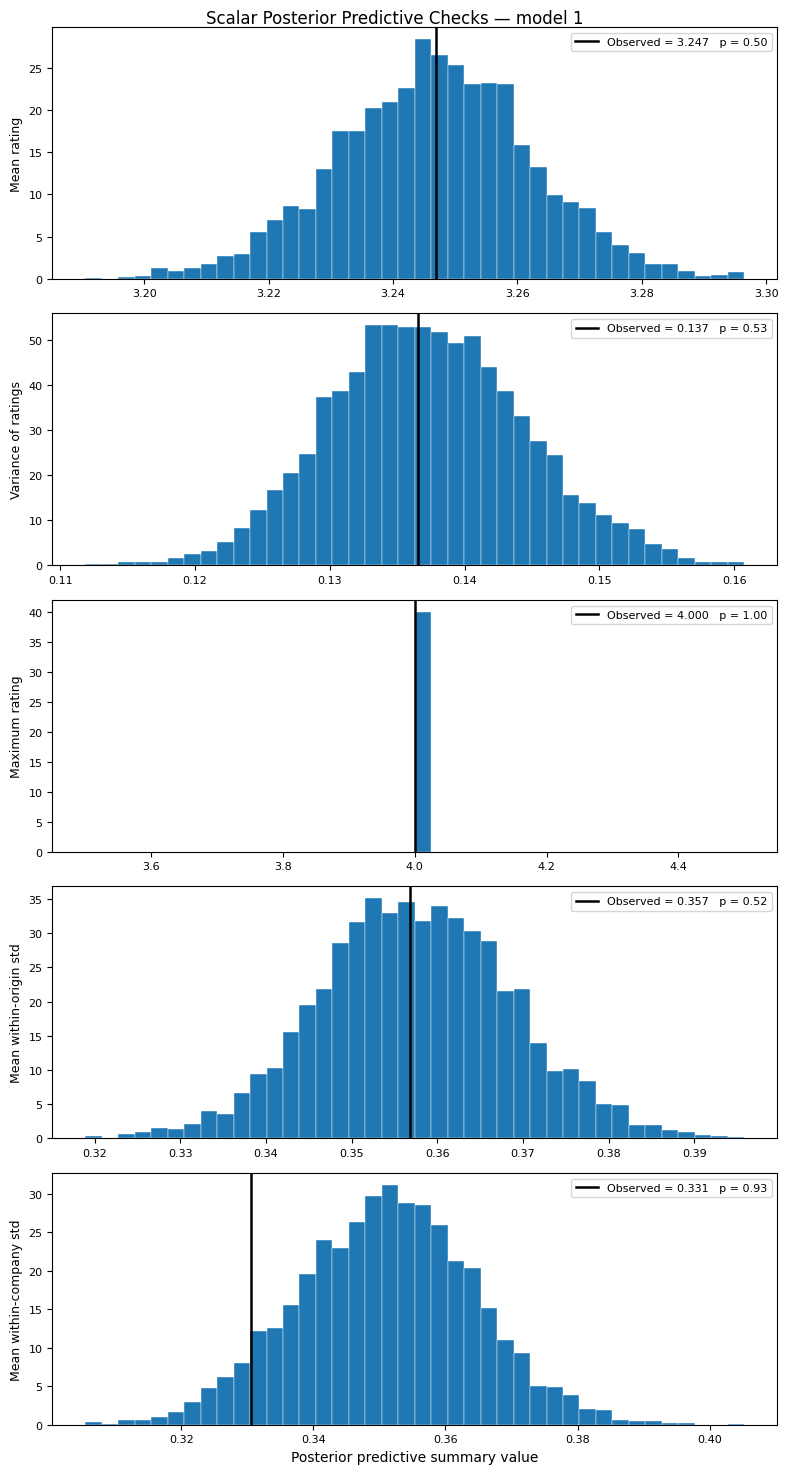

In [12]:
obs     = df["Rating"].values
y_rep   = rating_pred_vals          # already on real scale

rep_mean = y_rep.mean(axis=1)
rep_var  = y_rep.var(axis=1)
rep_max  = y_rep.max(axis=1)

# within-country std
country_sds_rep = np.zeros((num_draws, J_sorted1))
country_sds_obs = np.zeros(J_sorted1)
for i, country_name in enumerate(results11["country"]):
    idx = current_df[current_df["Country of Bean Origin"] == country_name].index.values
    if len(idx) > 1:
        country_sds_rep[:, i] = y_rep[:, idx].std(axis=1)
        country_sds_obs[i]    = obs[idx].std()
mean_country_sd_rep = country_sds_rep.mean(axis=1)
mean_country_sd_obs = country_sds_obs.mean()

# within-company std
company_sds_rep = np.zeros((num_draws, K_sorted))
company_sds_obs = np.zeros(K_sorted)
for i, comp_name in enumerate(results12["company"]):
    idx = current_df[current_df["Company Location"] == comp_name].index.values
    if len(idx) > 1:
        company_sds_rep[:, i] = y_rep[:, idx].std(axis=1)
        company_sds_obs[i]    = obs[idx].std()
mean_company_sd_rep = company_sds_rep.mean(axis=1)
mean_company_sd_obs = company_sds_obs.mean()

checks = [
    (rep_mean,           obs.mean(),          "Mean rating"),
    (rep_var,            obs.var(),           "Variance of ratings"),
    (rep_max,            obs.max(),           "Maximum rating"),
    (mean_country_sd_rep, mean_country_sd_obs, "Mean within-origin std"),
    (mean_company_sd_rep, mean_company_sd_obs, "Mean within-company std"),
]

fig, axes = plt.subplots(5, 1, figsize=(8, 15))
for ax, (rep_stat, obs_stat, ylabel) in zip(axes, checks):
    ax.hist(rep_stat, bins=40, density=True, edgecolor="white", linewidth=0.3)
    p_val = np.mean(rep_stat >= obs_stat)
    ax.axvline(obs_stat, color="k", linewidth=1.8,
               label=f"Observed = {obs_stat:.3f}   p = {p_val:.2f}")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel("Posterior predictive summary value", fontsize=10)
plt.suptitle("Scalar Posterior Predictive Checks — model 1", fontsize=12)
plt.tight_layout()
plt.show()

# Model 2

This model builds upon Model 1 by explicitly conditioning on the producer's recipe choices. By blocking the backdoor paths of cocoa percentage and vanilla usage, the geographic effects ($\alpha$ and $\gamma$) isolate the pure mechanical skill and terroir from regional recipe biases.

## 1. Mathematical Formulation

### Likelihood

$$
y_i \sim \text{OrderedLogistic}(\phi_i, c)
$$

### Linear Predictor

$$
\phi_i = \mu + \alpha_{j[i]} + \gamma_{k[i]} + \beta_{\text{cocoa}, k[i]} \cdot \text{logit\_cocoa}_i + \beta_{\text{vanilla}} \cdot \text{has\_vanilla}_i
$$

### Hierarchical Structure

In addition to the varying intercepts from Model 1, this model allows the impact of cocoa percentage to vary by producer location recognizing that different traditions handle high-bitterness recipes differently:

$$
\beta_{\text{cocoa}, k} \sim \text{Normal}(\mu_{\beta_{\text{cocoa}}}, \sigma_{\beta_{\text{cocoa}}})
$$

## 2. Priors

 Model 2 inherits the $c$, $\mu$, $\alpha$, $\gamma$, and $\lambda$ priors from Model 1. The following are the new additions.

### Prior for the Mean Cocoa Slope

$$
\mu_{\beta_{\text{cocoa}}} \sim \text{Normal}(0, 1)
$$

Because `logit_cocoa` is standardized, this prior states that a one-standard-deviation increase in the logit of cocoa percentage is expected to shift the log-odds of the rating by a value centered at 0, with 95% of the prior mass between -2 and 2. This is mildly regularizing, allowing the data to drive the direction of the cocoa effect without blowing up.

### Prior for the Cocoa Slope Standard Deviation

$$
\sigma_{\beta_{\text{cocoa}}} \sim \text{HalfNormal}(0, 0.5)
$$

This is a deliberately tighter prior than the intercept scale parameters. Slopes (how much the cocoa effect varies across countries) generally exhibit less variance than intercepts (baseline country skill). Setting a tighter prior of 0.5 regularizes the country-specific slopes, preventing the model from overfitting to small sample sizes within specific countries.

### Prior for the Vanilla Effect

$$
\beta_{\text{vanilla}} \sim \text{Normal}(0, 1)
$$

`has_vanilla` is a binary indicator (0 or 1). A normal prior with a standard deviation of 1 implies that adding vanilla typically shifts the log-odds of a bar's rating by an amount between -2 and 2. This is skeptical but open-minded, heavily penalizing the idea that vanilla acts as a "magic bullet" that guarantees a perfect or terrible score.

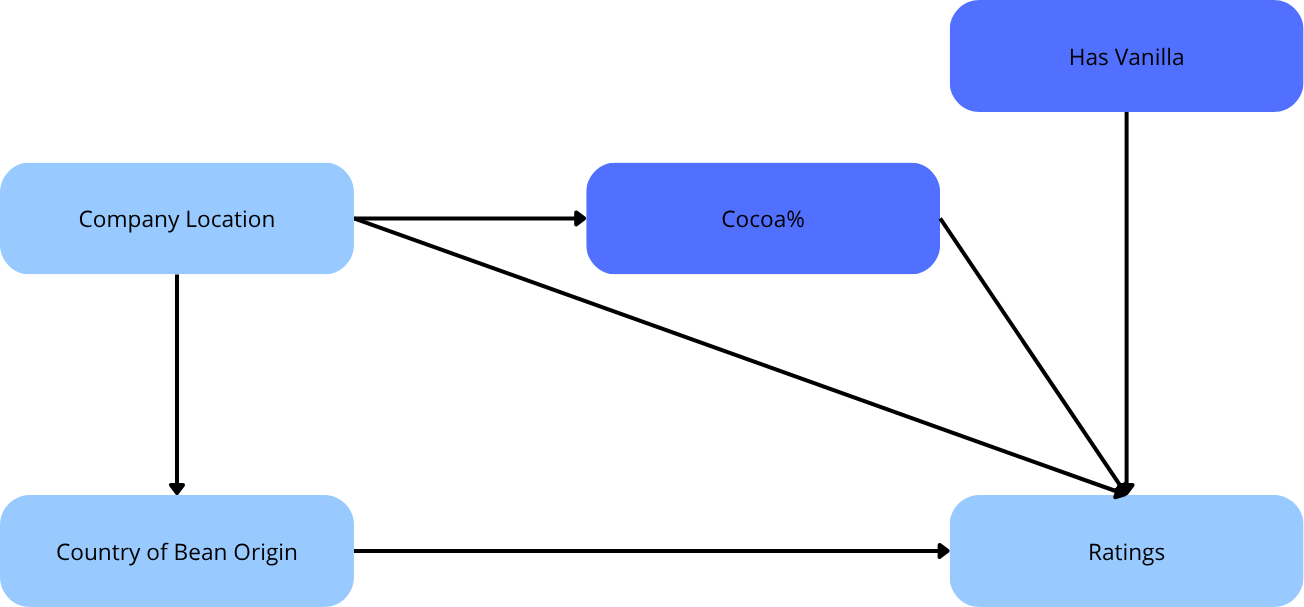

In [13]:
# ════════════════════════════════════════════════════════════
# MODEL 2 — DATA PREPARATION
# ════════════════════════════════════════════════════════════

# ── Cocoa % ───────────────────────────────────────────────
df['cocoa_prop'] = df['Cocoa Percent'].str.replace('%', '').astype(float) / 100.0
df['cocoa_prop'] = df['cocoa_prop'].clip(0.01, 0.99)
df['logit_cocoa'] = np.log(df['cocoa_prop'] / (1 - df['cocoa_prop']))
df['logit_cocoa_scaled'] = (
    (df['logit_cocoa'] - df['logit_cocoa'].mean()) / df['logit_cocoa'].std()
)

# ── Number of ingredients ─────────────────────────────────
# already normalized in the preprocessed CSV
df['n_ingredients_scaled'] = df['Number of ingredients norm']
print(f"NaNs n_ing: {df['n_ingredients_scaled'].isna().sum()}")
print(df[['Number of ingredients', 'n_ingredients_scaled']].head(5))

# ── Has vanilla ───────────────────────────────────────────
df['has_vanilla'] = df['Has vanilla'].astype(int)

# sanity checks — all should be 0
print(f"NaNs cocoa:        {df['logit_cocoa_scaled'].isna().sum()}")
print(f"NaNs n_ing:        {df['n_ingredients_scaled'].isna().sum()}")
print(f"NaNs has_vanilla:  {df['has_vanilla'].isna().sum()}")
print(f"has_vanilla unique: {sorted(df['has_vanilla'].unique())}")


NaNs n_ing: 0
   Number of ingredients  n_ingredients_scaled
0                    3.0              0.345818
1                    3.0              0.345818
2                    3.0              0.345818
3                    3.0              0.345818
4                    3.0              0.345818
NaNs cocoa:        0
NaNs n_ing:        0
NaNs has_vanilla:  0
has_vanilla unique: [np.int64(0), np.int64(1)]


In [14]:
print(df[['Cocoa Percent', 'logit_cocoa_scaled',
          'Number of ingredients', 'n_ingredients_scaled', 'has_vanilla']].head(5))

  Cocoa Percent  logit_cocoa_scaled  Number of ingredients  \
0           75%            0.894445                    3.0   
1           70%           -0.417679                    3.0   
2           70%           -0.417679                    3.0   
3           70%           -0.417679                    3.0   
4           80%            2.396446                    3.0   

   n_ingredients_scaled  has_vanilla  
0              0.345818            0  
1              0.345818            0  
2              0.345818            0  
3              0.345818            0  
4              0.345818            0  


In [16]:
# ════════════════════════════════════════════════════════════
# MODEL 2 — PRIOR PREDICTIVE CHECK
# ════════════════════════════════════════════════════════════

prior_model2 = CmdStanModel(stan_file="prior_model2.stan")

prior_data2 = {
    "N": len(df),
    "J": J,
    "K": K,
    "C": C,
    "origin":          df['Bean Origin ID'].tolist(),
    "producer":        df['Company Location ID'].tolist(),
    "origin_location": origin_location,
    "cocoa_logit":     df['logit_cocoa_scaled'].tolist(),
    "has_vanilla":     df['has_vanilla'].tolist(),
}

prior_fit2 = prior_model2.sample(
    data=prior_data2,
    fixed_param=True,
    iter_sampling=2000,
    chains=1,
    seed=42,
    show_progress=False,
)

# pull prior samples
rating_pred_prior2   = prior_fit2.stan_variable("rating_pred")
mu_global_prior2     = prior_fit2.stan_variable("mu_global")
sigma_origin_prior2  = prior_fit2.stan_variable("sigma_origin")
sigma_prod_prior2    = prior_fit2.stan_variable("sigma_producer")
sigma_lam_prior2     = prior_fit2.stan_variable("sigma_lambda")
alpha_prior2         = prior_fit2.stan_variable("alpha")
gamma_prior2         = prior_fit2.stan_variable("gamma")
mu_beta_cocoa_prior2 = prior_fit2.stan_variable("mu_beta_cocoa")
sigma_bc_prior2      = prior_fit2.stan_variable("sigma_beta_cocoa")
beta_vanilla_prior2  = prior_fit2.stan_variable("beta_vanilla") 
c_prior_draws2       = prior_fit2.stan_variable("c")


10:46:32 - cmdstanpy - INFO - CmdStan start processing
10:46:32 - cmdstanpy - INFO - Chain [1] start processing
10:46:34 - cmdstanpy - INFO - Chain [1] done processing


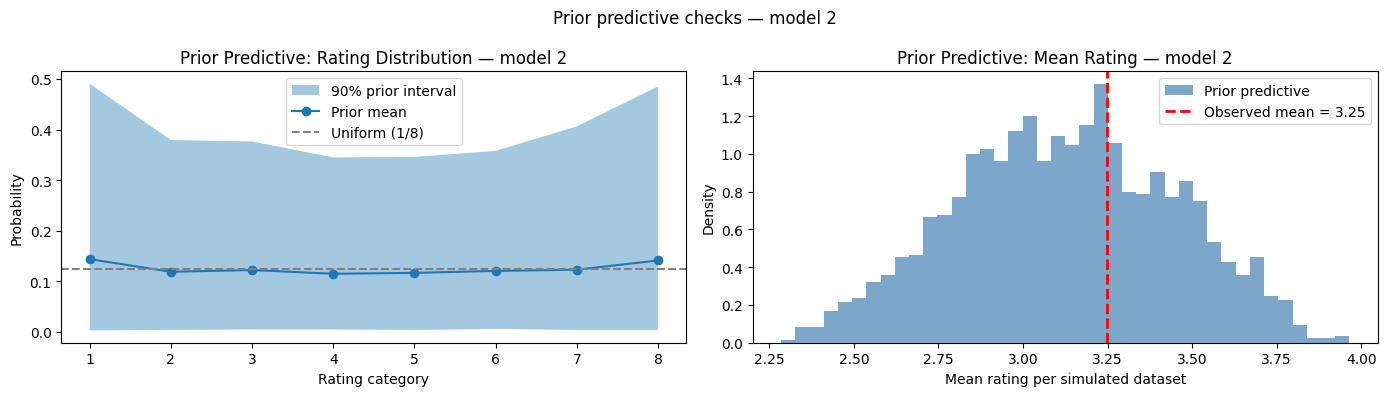

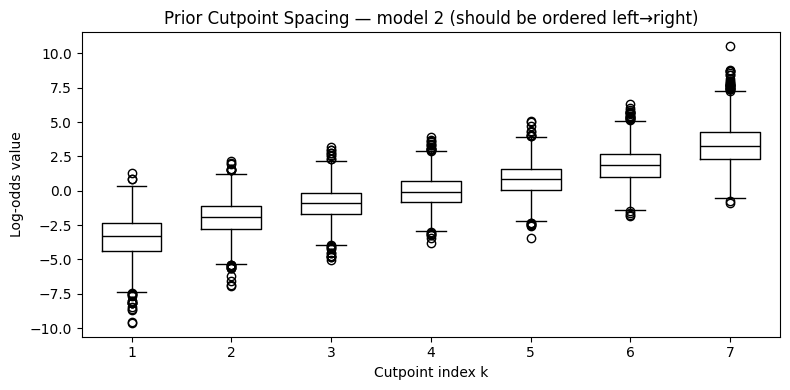

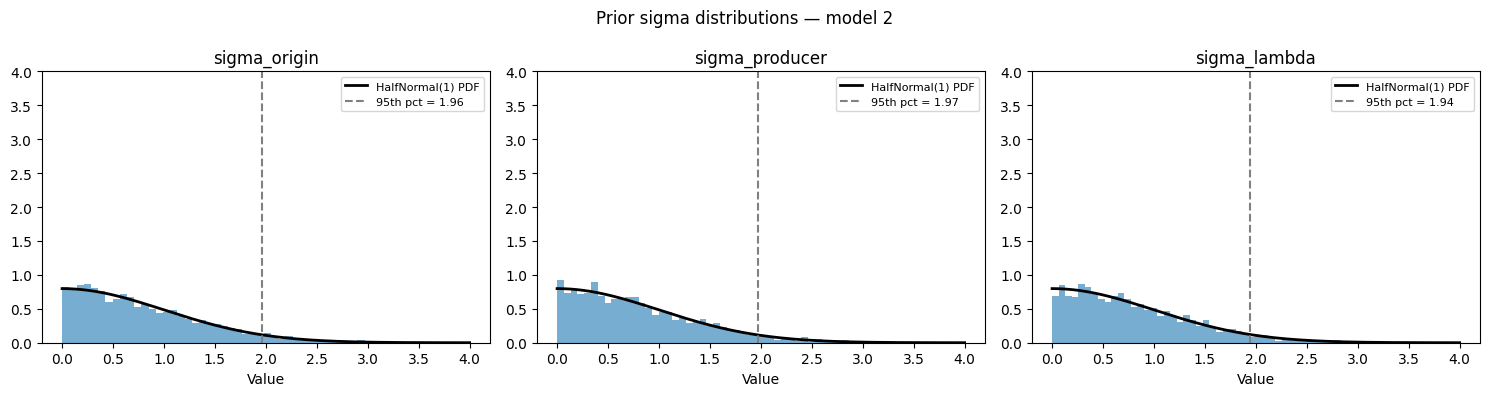

In [17]:
# ── Prior predictive: rating distribution ─────────────────
pred_counts_p2 = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C), 1, rating_pred_prior2
)
pred_probs_p2 = pred_counts_p2 / pred_counts_p2.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.fill_between(range(1, C + 1),
                np.percentile(pred_probs_p2, 5,  axis=0),
                np.percentile(pred_probs_p2, 95, axis=0),
                alpha=0.4, label="90% prior interval")
ax.plot(range(1, C + 1), pred_probs_p2.mean(axis=0), marker='o', label="Prior mean")
ax.axhline(1 / C, ls='--', color='gray', label=f"Uniform (1/{C})")
ax.set_xlabel("Rating category"); ax.set_ylabel("Probability")
ax.set_title("Prior Predictive: Rating Distribution — model 2")
ax.legend()

# ── Prior predictive: mean rating ─────────────────────────
id_to_rating = np.vectorize(inv_rating_map.get)
prior2_vals  = id_to_rating(rating_pred_prior2)

ax = axes[1]
ax.hist(prior2_vals.mean(axis=1), bins=40, density=True, alpha=0.7,
        color="steelblue", label="Prior predictive")
ax.axvline(df["Rating"].mean(), color="red", lw=2, ls="--",
           label=f"Observed mean = {df['Rating'].mean():.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Prior Predictive: Mean Rating — model 2")
ax.legend()

plt.suptitle("Prior predictive checks — model 2")
plt.tight_layout()
plt.show()
# ── Prior cutpoint spacing ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for k in range(C - 1):
    ax.boxplot(c_prior_draws2[:, k], positions=[k + 1], widths=0.6,
               medianprops=dict(color='black'))
ax.set_xlabel("Cutpoint index k")
ax.set_ylabel("Log-odds value")
ax.set_title("Prior Cutpoint Spacing — model 2 (should be ordered left→right)")
plt.tight_layout()
plt.show()

# ── Prior sigma distributions ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_s = np.linspace(0, 4, 300)
ref = stats.halfnorm.pdf(x_s, scale=1.0)

for ax, samples, name in zip(
    axes,
    [sigma_origin_prior2, sigma_prod_prior2, sigma_lam_prior2],
    ["sigma_origin", "sigma_producer", "sigma_lambda"]
):
    ax.hist(samples, bins=50, density=True, alpha=0.6)
    ax.plot(x_s, ref, 'k-', lw=2, label="HalfNormal(1) PDF")
    ax.axvline(np.percentile(samples, 95), ls='--', color='gray',
               label=f"95th pct = {np.percentile(samples, 95):.2f}")
    ax.set_title(name); ax.set_xlabel("Value"); ax.legend(fontsize=8)
    ax.set_ylim([0, 4])

plt.suptitle("Prior sigma distributions — model 2")
plt.tight_layout()
plt.show()

In [19]:
# ════════════════════════════════════════════════════════════
# MODEL 2 — POSTERIOR FIT
# ════════════════════════════════════════════════════════════

model_2_fit = CmdStanModel(stan_file="model_2.stan")

data_sim2 = {
    "N": len(df),
    "J": J,
    "K": K,
    "C": C,
    "origin":          df['Bean Origin ID'].tolist(),
    "producer":        df['Company Location ID'].tolist(),
    "rating":          df['rating_id'].tolist(),
    "origin_location": origin_location,
    "cocoa_logit":     df['logit_cocoa_scaled'].tolist(),
    "has_vanilla":     df['has_vanilla'].tolist(),
}

fit2 = model_2_fit.sample(
    data=data_sim2,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_progress=True,
)
# ── posterior variable extraction ─────────────────────────
rating_pred_post2       = fit2.stan_variable("rating_pred")
alpha_samples2          = fit2.stan_variable("alpha")
gamma_samples2          = fit2.stan_variable("gamma")
lambda_samples2         = fit2.stan_variable("lambda")
sigma_origin2           = fit2.stan_variable("sigma_origin")
sigma_producer2         = fit2.stan_variable("sigma_producer")
sigma_lambda2           = fit2.stan_variable("sigma_lambda")
mu_global_samples2      = fit2.stan_variable("mu_global")
mu_beta_cocoa_samples2  = fit2.stan_variable("mu_beta_cocoa")    # (draws,)
beta_cocoa_samples2     = fit2.stan_variable("beta_cocoa")       # (draws, K)
sigma_bc2               = fit2.stan_variable("sigma_beta_cocoa") # (draws,)
# mu_beta_vanilla_samples2 = fit2.stan_variable("mu_beta_vanilla") # (draws,)
beta_vanilla_samples2   = fit2.stan_variable("beta_vanilla")     # (draws, K)
# sigma_bv2               = fit2.stan_variable("sigma_beta_vanilla")# (draws,)
c_samples2              = fit2.stan_variable("c")


# map category ids → real rating values, used everywhere below
rating_pred_vals2 = id_to_rating(rating_pred_post2)             # (draws, N)

10:59:08 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

11:00:28 - cmdstanpy - INFO - CmdStan done processing.
11:00:28 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -501.522, but should be greater than the previous element, -501.522 (in 'model_2.stan', line 74, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 2 is -503.263, but should be greater than the previous element, -503.263 (in 'model_2.stan', line 74, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -123.381, but should be greater than the previous element, -123.381 (in 'model_2.stan', line 74, column 2 to column 36)
	Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is -29.5042, but should be greater than the previous element, -29.5042 (in 'model_2.stan', line 74, column 2 to column 36)
	Exception: ordered_logistic: Lo

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


Parameters with R-hat > 1.01: 0

Parameters with ESS < 400: 0


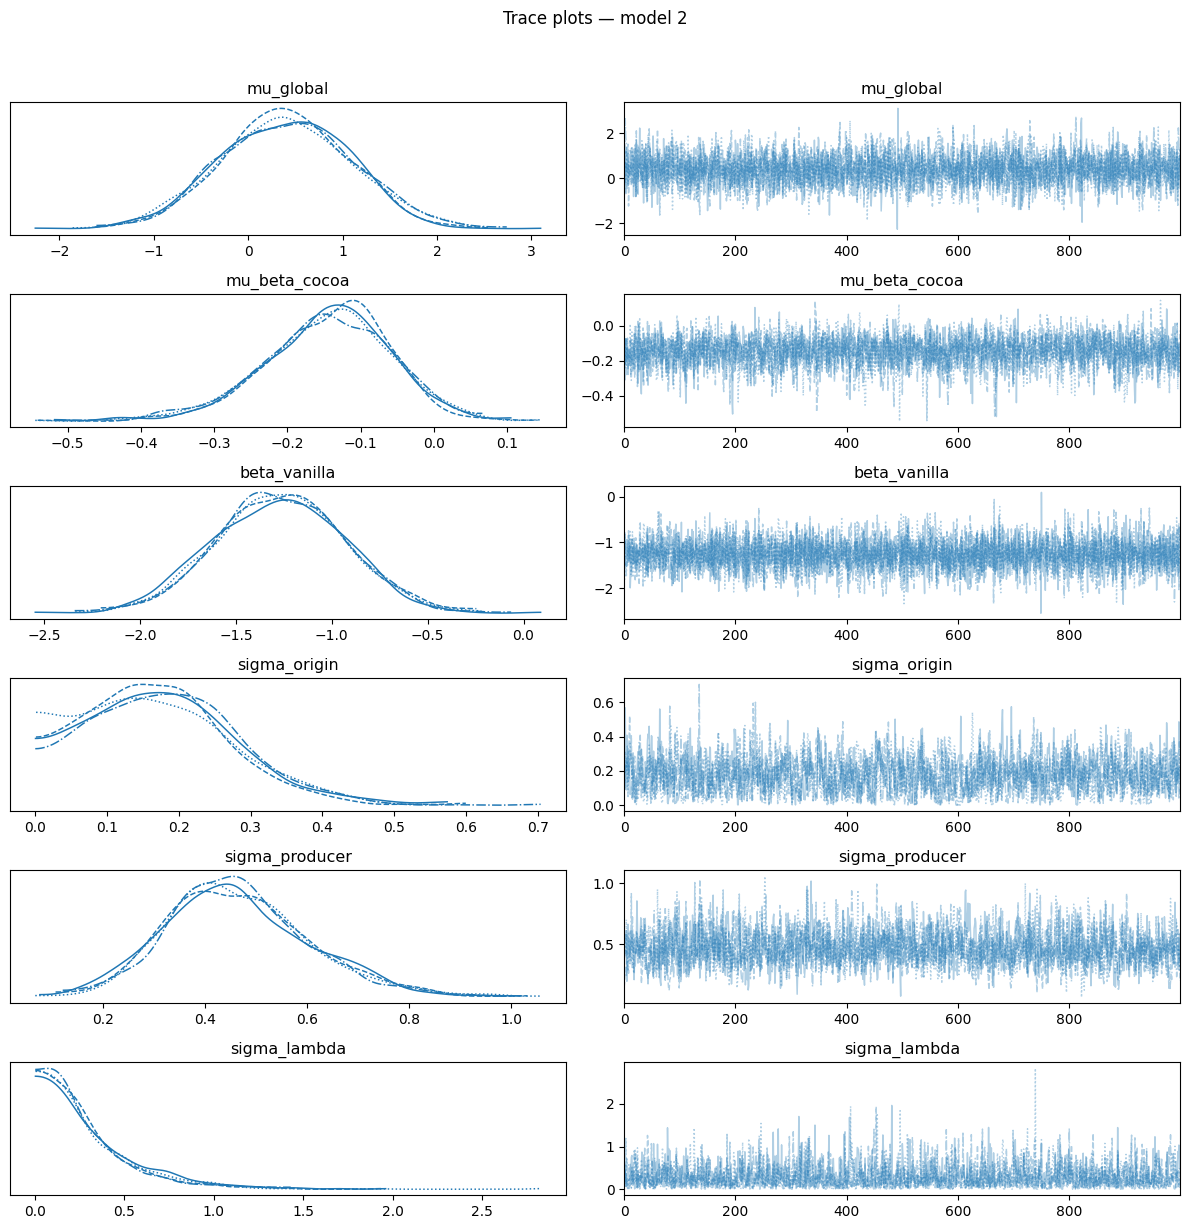

In [20]:
# ── Convergence diagnostics ───────────────────────────────
print(fit2.diagnose())

idata2    = az.from_cmdstanpy(fit2)
summary2  = az.summary(idata2)
bad_rhat2 = summary2[summary2['r_hat'] > 1.01]
bad_ess2  = summary2[summary2['ess_bulk'] < 400]

print(f"\nParameters with R-hat > 1.01: {len(bad_rhat2)}")
if len(bad_rhat2) > 0:
    print(bad_rhat2[['mean', 'sd', 'r_hat', 'ess_bulk']].head(20))

print(f"\nParameters with ESS < 400: {len(bad_ess2)}")
if len(bad_ess2) > 0:
    print(bad_ess2[['mean', 'sd', 'r_hat', 'ess_bulk']].head(20))

# trace plots for scalar params only (vectors like beta_cocoa skipped here)
az.plot_trace(idata2, var_names=["mu_global", "mu_beta_cocoa", 
                                  "beta_vanilla", "sigma_origin",
                                  "sigma_producer", "sigma_lambda"])
plt.suptitle("Trace plots — model 2", y=1.02)
plt.tight_layout()
plt.show()

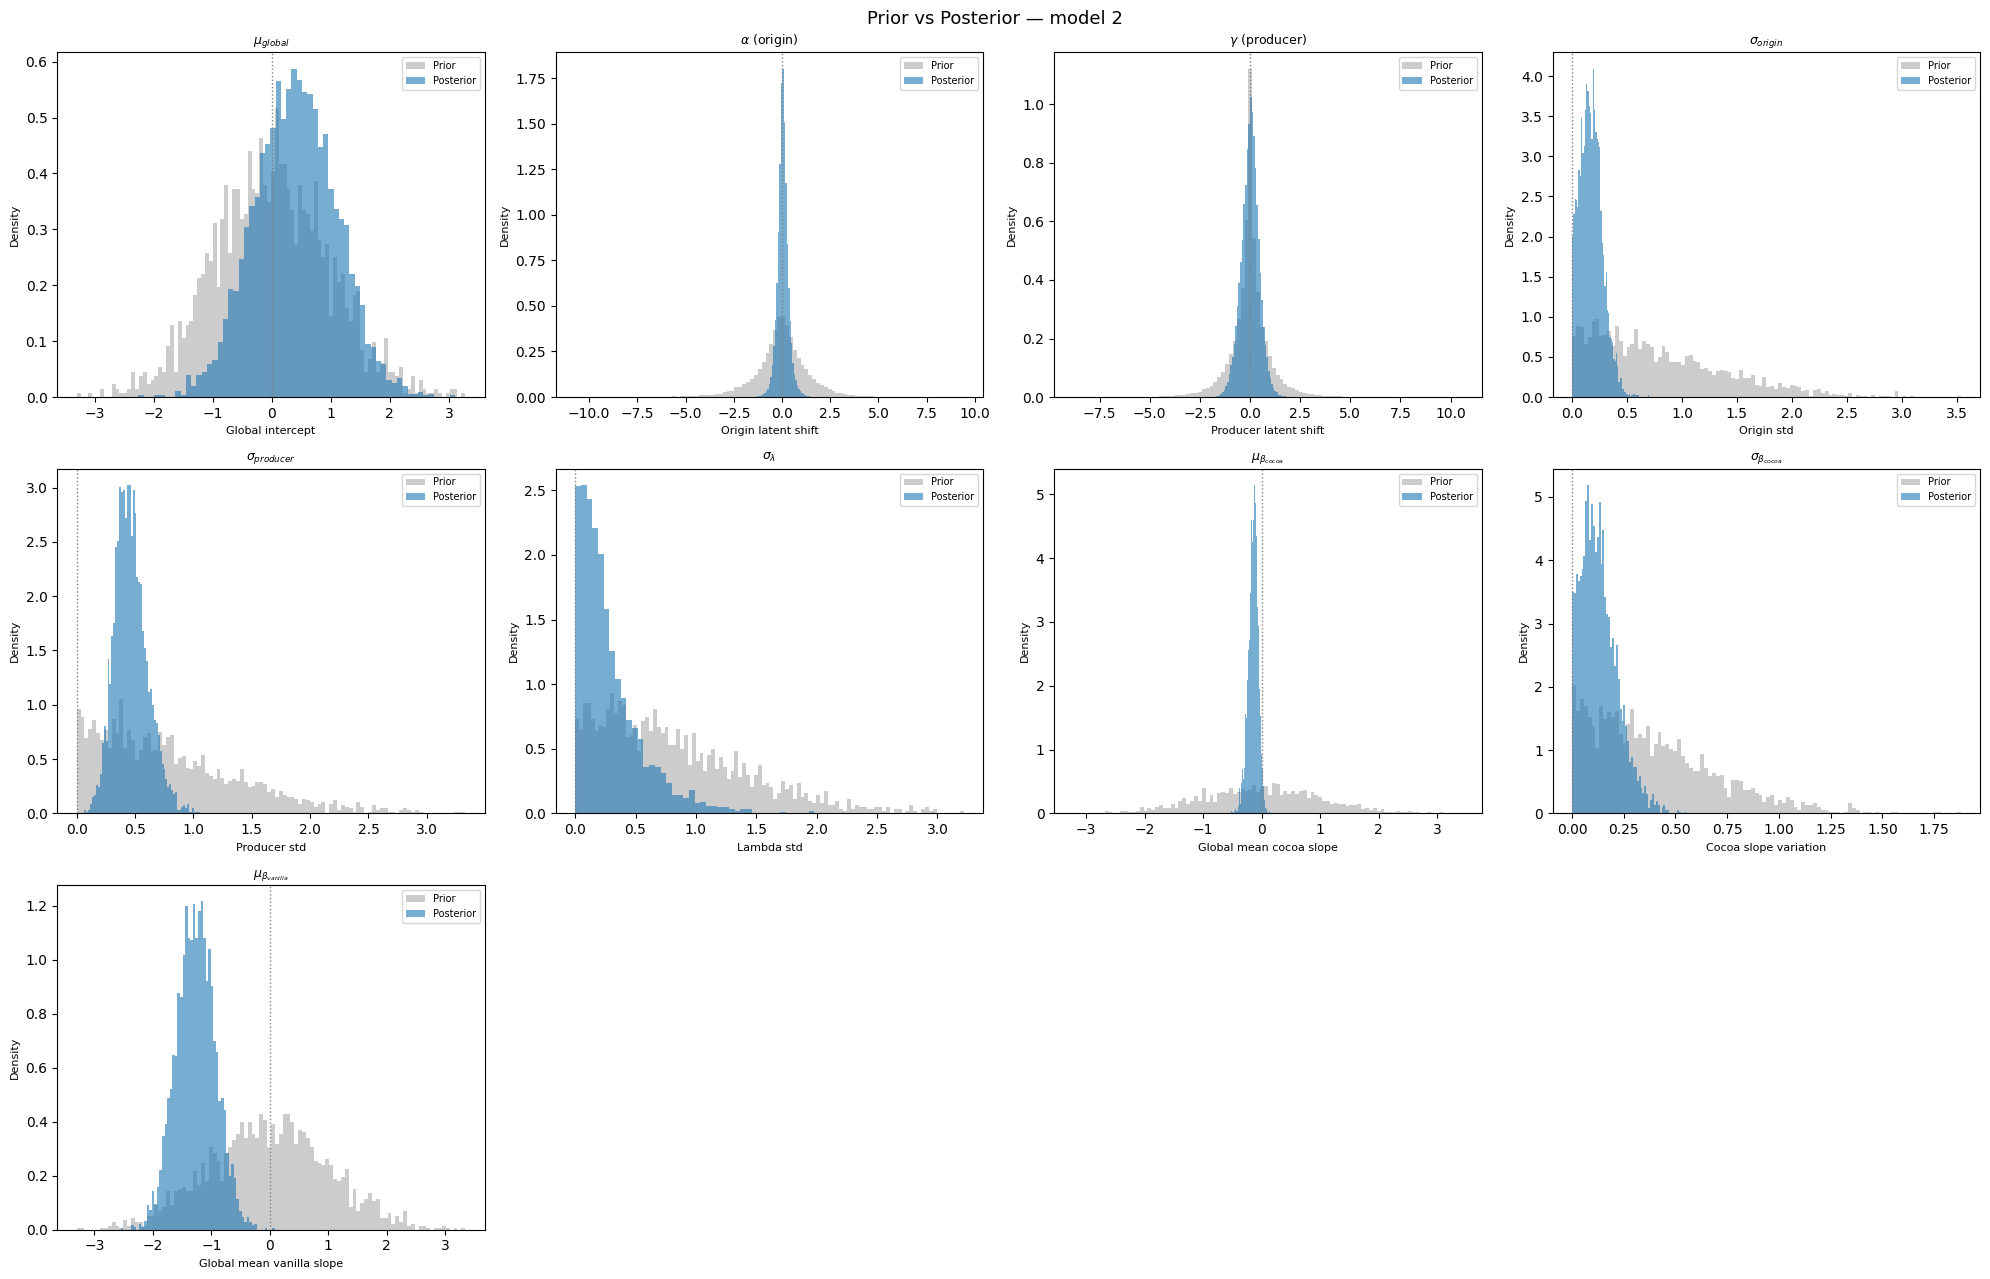

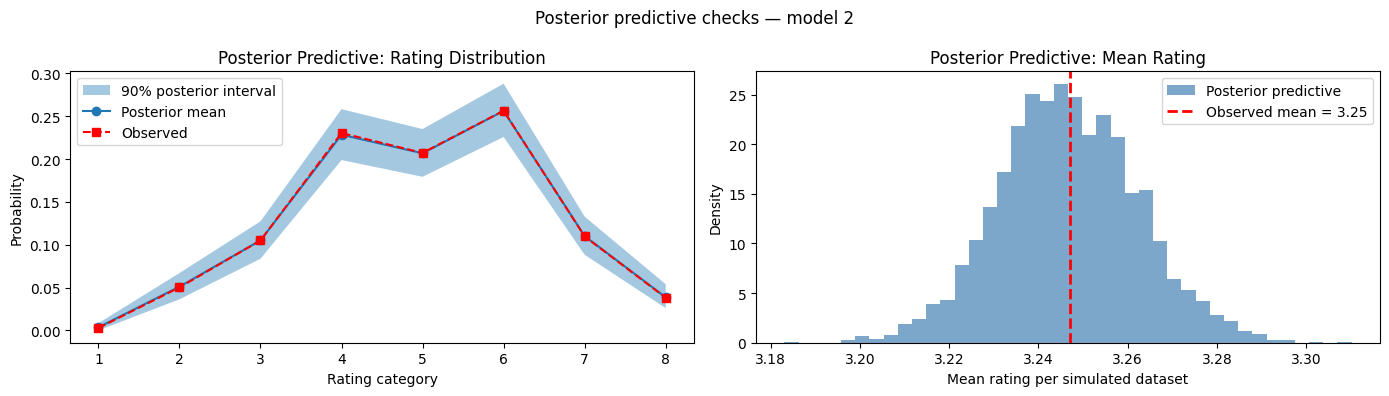

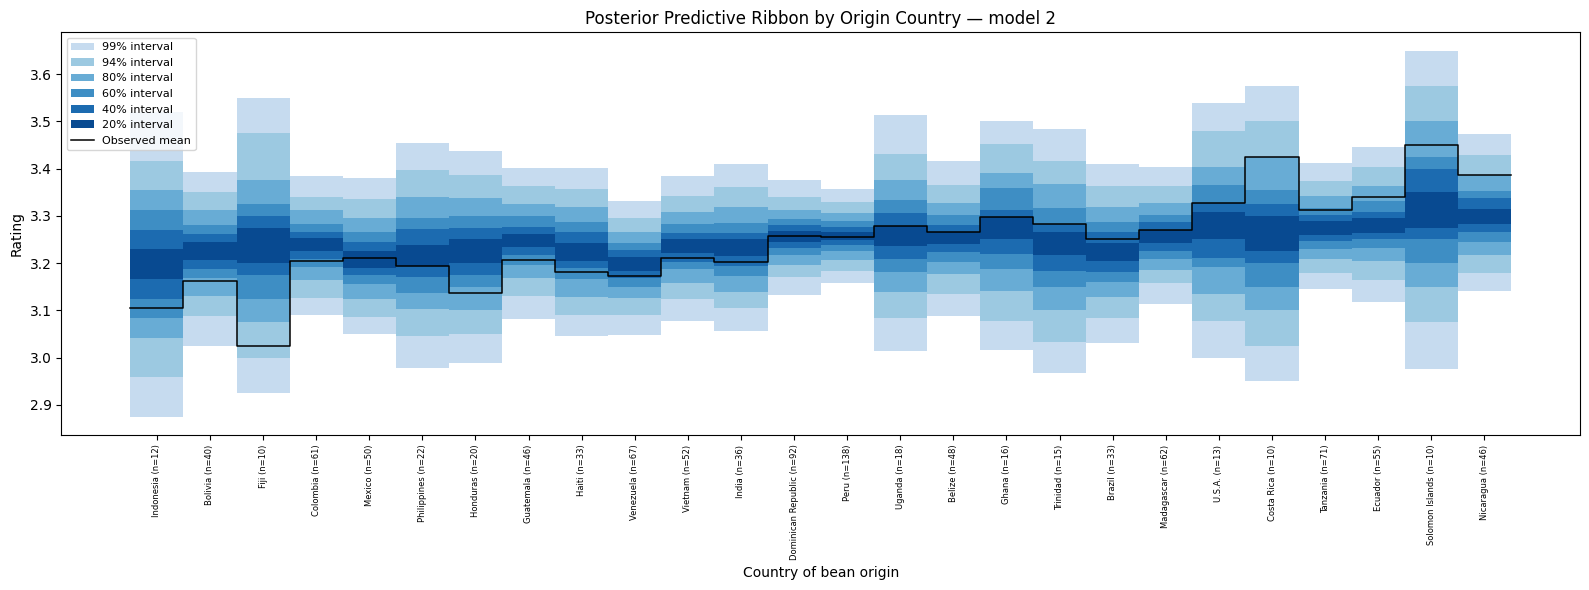

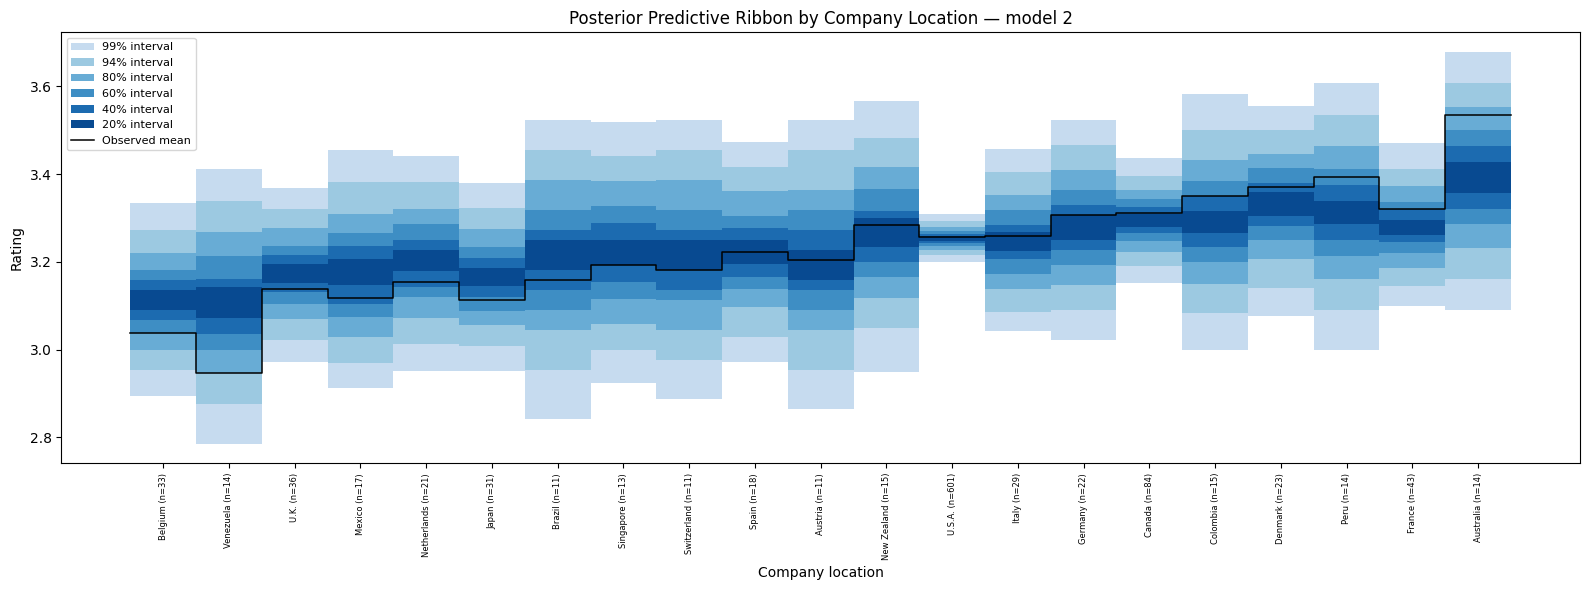

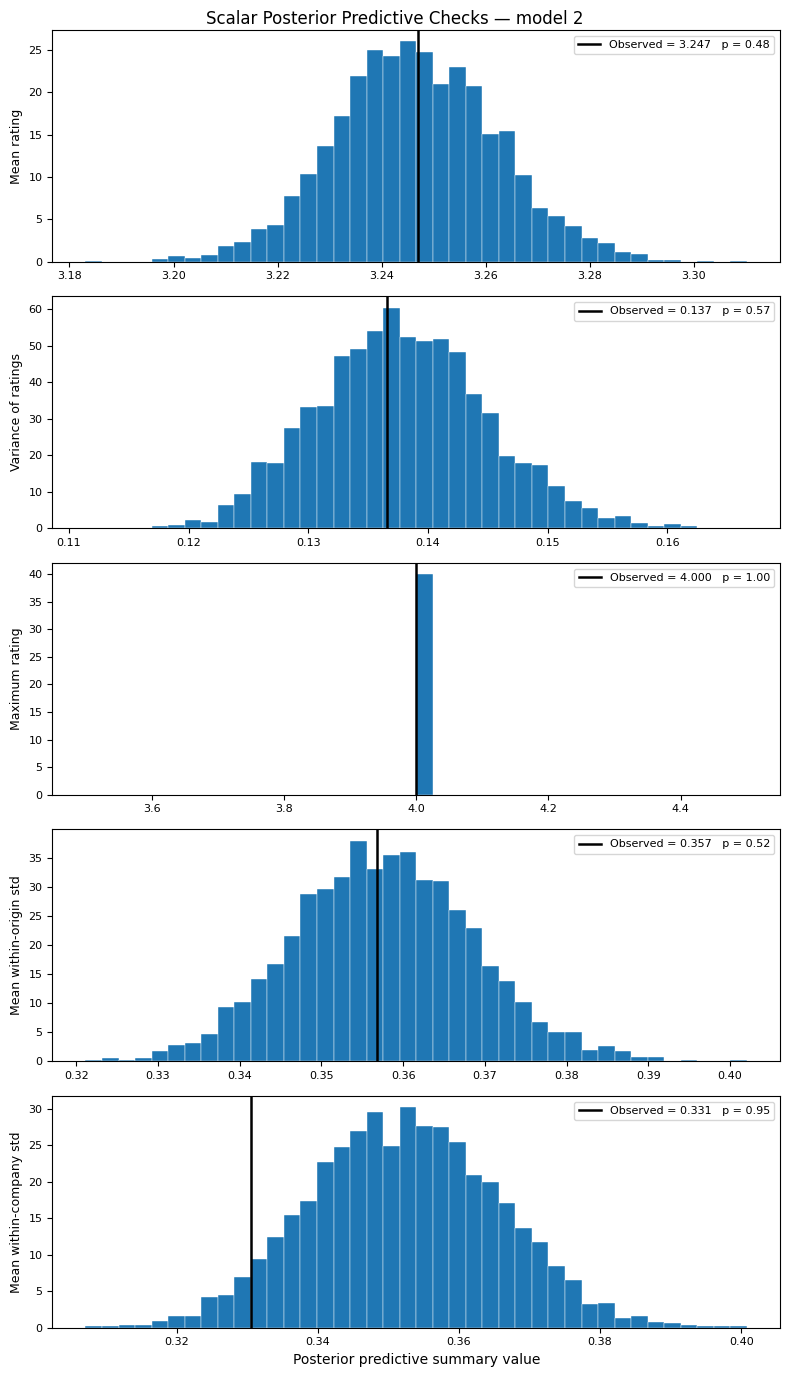

In [26]:
# ── prior vs posterior — updated panels ───────────────────
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
axes = axes.flatten()

panels = [
    (mu_global_samples2,          mu_global_prior2,
     r"$\mu_{global}$",           "Global intercept"),
    (alpha_samples2.flatten(),    alpha_prior2.flatten(),
     r"$\alpha$ (origin)",        "Origin latent shift"),
    (gamma_samples2.flatten(),    gamma_prior2.flatten(),
     r"$\gamma$ (producer)",      "Producer latent shift"),
    (sigma_origin2,               sigma_origin_prior2,
     r"$\sigma_{origin}$",        "Origin std"),
    (sigma_producer2,             sigma_prod_prior2,
     r"$\sigma_{producer}$",      "Producer std"),
    (sigma_lambda2,               sigma_lam_prior2,
     r"$\sigma_{\lambda}$",       "Lambda std"),
    (mu_beta_cocoa_samples2,      mu_beta_cocoa_prior2,
     r"$\mu_{\beta_{cocoa}}$",    "Global mean cocoa slope"),
    (sigma_bc2,                   sigma_bc_prior2,
     r"$\sigma_{\beta_{cocoa}}$", "Cocoa slope variation"),
    (beta_vanilla_samples2,        beta_vanilla_prior2,
     r"$\mu_{\beta_{vanilla}}$",  "Global mean vanilla slope"),
    # (mu_beta_vanilla_samples2,    mu_beta_vanilla_prior2,
    #  r"$\mu_{\beta_{vanilla}}$",  "Global mean vanilla slope"),
    # (sigma_bv2,                   sigma_bv_prior2,
    #  r"$\sigma_{\beta_{vanilla}}$","Vanilla slope variation"),
]

for ax, (post, prior, title, xlabel) in zip(axes, panels):
    ax.hist(prior, bins=100, density=True, alpha=0.4, color="gray", label="Prior")
    ax.hist(post,  bins=60,  density=True, alpha=0.6, label="Posterior")
    ax.axvline(0, color="gray", ls=":", lw=1)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.legend(fontsize=7)

for ax in axes[len(panels):]:
    ax.set_visible(False)

plt.suptitle("Prior vs Posterior — model 2", fontsize=13)
plt.tight_layout()
plt.show()

# ── Posterior predictive: overall distribution ────────────
pred_counts2 = np.apply_along_axis(
    lambda x: np.bincount(x.astype(int) - 1, minlength=C), 1, rating_pred_post2
)
pred_probs2 = pred_counts2 / pred_counts2.sum(axis=1, keepdims=True)
obs_counts  = np.bincount(df['rating_id'].values.astype(int) - 1, minlength=C)
obs_probs   = obs_counts / obs_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.fill_between(range(1, C + 1),
                np.percentile(pred_probs2, 5,  axis=0),
                np.percentile(pred_probs2, 95, axis=0),
                alpha=0.4, label="90% posterior interval")
ax.plot(range(1, C + 1), pred_probs2.mean(axis=0), marker='o', label="Posterior mean")
ax.plot(range(1, C + 1), obs_probs, marker='s', color='red',
        ls='--', label="Observed")
ax.set_xlabel("Rating category"); ax.set_ylabel("Probability")
ax.set_title("Posterior Predictive: Rating Distribution")
ax.legend()

ax = axes[1]
ax.hist(rating_pred_vals2.mean(axis=1), bins=40, density=True,
        alpha=0.7, color="steelblue", label="Posterior predictive")
ax.axvline(df["Rating"].mean(), color="red", lw=2, ls="--",
           label=f"Observed mean = {df['Rating'].mean():.2f}")
ax.set_xlabel("Mean rating per simulated dataset")
ax.set_ylabel("Density")
ax.set_title("Posterior Predictive: Mean Rating")
ax.legend()

plt.suptitle("Posterior predictive checks — model 2")
plt.tight_layout()
plt.show()

# ── Ribbon plot: bean origin ──────────────────────────────
current_df    = df.copy().reset_index(drop=True)
countries     = sorted(current_df["Country of Bean Origin"].unique())
country_idx   = {c: i + 1 for i, c in enumerate(countries)}
current_df["country_id"] = current_df["Country of Bean Origin"].map(country_idx)
counts_origin = current_df["Country of Bean Origin"].value_counts().to_dict()

mu_origin_total2 = mu_global_samples2[:, None] + alpha_samples2  # (draws, J)

results21 = pd.DataFrame({
    "country":     countries,
    "mu_mean":     mu_origin_total2.mean(axis=0),
    "mu_lower_94": np.percentile(mu_origin_total2, 3,  axis=0),
    "mu_upper_94": np.percentile(mu_origin_total2, 97, axis=0),
    "n_bars":      [counts_origin.get(c, 0) for c in countries],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

obs_per_country2  = current_df.groupby("country_id")["Rating"].mean()
obs_sorted_orig2  = results21["country"].map(
    lambda c: obs_per_country2[country_idx[c]]
).values

J_sorted2  = len(results21)
x2         = np.arange(1, J_sorted2 + 1)
num_draws2 = rating_pred_vals2.shape[0]

post_pred_orig2 = np.zeros((num_draws2, J_sorted2))
for i, cname in enumerate(results21["country"]):
    idx = current_df[current_df["Country of Bean Origin"] == cname].index.values
    post_pred_orig2[:, i] = rating_pred_vals2[:, idx].mean(axis=1)

def step_edges(values, x):
    return (np.concatenate([x - 0.5, x[-1:] + 0.5]),
            np.concatenate([[values[0]], values]))

levels = [99, 94, 80, 60, 40, 20]
cmap   = matplotlib.colormaps["Blues"]
colors = [mcolors.to_hex(cmap(f)) for f in np.linspace(0.25, 0.9, len(levels))]

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo = np.percentile(post_pred_orig2, (100 - lev) / 2,       axis=0)
    hi = np.percentile(post_pred_orig2, 100 - (100 - lev) / 2, axis=0)
    e, ls = step_edges(lo, x2); _, hs = step_edges(hi, x2)
    ax.fill_between(e, ls, hs, step="pre", color=color,
                    linewidth=0, label=f"{lev}% interval")

e, os_ = step_edges(obs_sorted_orig2, x2)
ax.step(e, os_, where="pre", color="black", linewidth=1.1, label="Observed mean")
ax.set_xticks(x2)
ax.set_xticklabels(
    [f"{r['country']} (n={r['n_bars']})" for _, r in results21.iterrows()],
    rotation=90, fontsize=6)
ax.set_xlabel("Country of bean origin"); ax.set_ylabel("Rating")
ax.set_title("Posterior Predictive Ribbon by Origin Country — model 2")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


# ── Ribbon plot: company location ─────────────────────────
company_locs  = sorted(current_df["Company Location"].unique())
company_idx   = {c: i + 1 for i, c in enumerate(company_locs)}
current_df["company_id"] = current_df["Company Location"].map(company_idx)
counts_company = current_df["Company Location"].value_counts().to_dict()

mu_company_total2 = mu_global_samples2[:, None] + gamma_samples2  # (draws, K)

results22 = pd.DataFrame({
    "company":     company_locs,
    "mu_mean":     mu_company_total2.mean(axis=0),
    "mu_lower_94": np.percentile(mu_company_total2, 3,  axis=0),
    "mu_upper_94": np.percentile(mu_company_total2, 97, axis=0),
    "n_bars":      [counts_company.get(c, 0) for c in company_locs],
}).sort_values("mu_mean", ascending=True).reset_index(drop=True)

obs_per_company2   = current_df.groupby("company_id")["Rating"].mean()
obs_sorted_comp2   = results22["company"].map(
    lambda c: obs_per_company2[company_idx[c]]
).values

K_sorted2 = len(results22)
x3        = np.arange(1, K_sorted2 + 1)

post_pred_comp2 = np.zeros((num_draws2, K_sorted2))
for i, cname in enumerate(results22["company"]):
    idx = current_df[current_df["Company Location"] == cname].index.values
    post_pred_comp2[:, i] = rating_pred_vals2[:, idx].mean(axis=1)

fig, ax = plt.subplots(figsize=(16, 6))
for lev, color in zip(levels, colors):
    lo = np.percentile(post_pred_comp2, (100 - lev) / 2,       axis=0)
    hi = np.percentile(post_pred_comp2, 100 - (100 - lev) / 2, axis=0)
    e, ls = step_edges(lo, x3); _, hs = step_edges(hi, x3)
    ax.fill_between(e, ls, hs, step="pre", color=color,
                    linewidth=0, label=f"{lev}% interval")

e, cs_ = step_edges(obs_sorted_comp2, x3)
ax.step(e, cs_, where="pre", color="black", linewidth=1.1, label="Observed mean")
ax.set_xticks(x3)
ax.set_xticklabels(
    [f"{r['company']} (n={r['n_bars']})" for _, r in results22.iterrows()],
    rotation=90, fontsize=6)
ax.set_xlabel("Company location"); ax.set_ylabel("Rating")
ax.set_title("Posterior Predictive Ribbon by Company Location — model 2")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


# ── Scalar posterior predictive checks ───────────────────
obs   = df["Rating"].values
y_rep = rating_pred_vals2

rep_mean = y_rep.mean(axis=1)
rep_var  = y_rep.var(axis=1)
rep_max  = y_rep.max(axis=1)

country_sds_rep = np.zeros((num_draws2, J_sorted2))
country_sds_obs = np.zeros(J_sorted2)
for i, cname in enumerate(results21["country"]):
    idx = current_df[current_df["Country of Bean Origin"] == cname].index.values
    if len(idx) > 1:
        country_sds_rep[:, i] = y_rep[:, idx].std(axis=1)
        country_sds_obs[i]    = obs[idx].std()

company_sds_rep = np.zeros((num_draws2, K_sorted2))
company_sds_obs = np.zeros(K_sorted2)
for i, cname in enumerate(results22["company"]):
    idx = current_df[current_df["Company Location"] == cname].index.values
    if len(idx) > 1:
        company_sds_rep[:, i] = y_rep[:, idx].std(axis=1)
        company_sds_obs[i]    = obs[idx].std()

checks = [
    (rep_mean,                        obs.mean(),                    "Mean rating"),
    (rep_var,                         obs.var(),                     "Variance of ratings"),
    (rep_max,                         obs.max(),                     "Maximum rating"),
    (country_sds_rep.mean(axis=1),    country_sds_obs.mean(),        "Mean within-origin std"),
    (company_sds_rep.mean(axis=1),    company_sds_obs.mean(),        "Mean within-company std"),
]

fig, axes = plt.subplots(5, 1, figsize=(8, 14))
for ax, (rep_stat, obs_stat, ylabel) in zip(axes, checks):
    ax.hist(rep_stat, bins=40, density=True, edgecolor="white", linewidth=0.3)
    p_val = np.mean(rep_stat >= obs_stat)
    ax.axvline(obs_stat, color="k", linewidth=1.8,
               label=f"Observed = {obs_stat:.3f}   p = {p_val:.2f}")
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel("Posterior predictive summary value", fontsize=10)
plt.suptitle("Scalar Posterior Predictive Checks — model 2", fontsize=12)
plt.tight_layout()
plt.show()

old:

## Model comapirson

Both models were compared using two information criteria: WAIC 
(Widely Applicable Information Criterion) and PSIS-LOO 
(Pareto-Smoothed Importance Sampling Leave-One-Out Cross-Validation), 
computed via ArviZ from the log-likelihood values stored in the 
generated quantities block of each model.

### WAIC

         rank    elpd_waic     p_waic  elpd_diff    weight         se  \
Model 2     0 -1911.585046  31.372630   0.000000  0.881201  18.866272   
Model 1     1 -1918.143101  26.208045   6.558054  0.118799  18.957899   

              dse  warning scale  
Model 2  0.000000     True   log  
Model 1  4.271263    False   log  


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


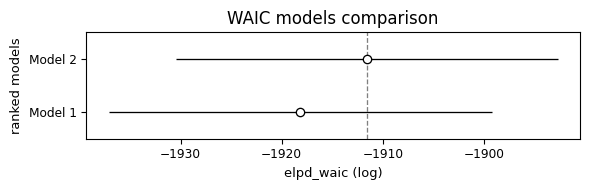

In [24]:
comp_dict = {
    "Model 1": fit1,
    "Model 2": fit2
}
comp_waic = az.compare(comp_dict, ic="waic")
print(comp_waic)

az.plot_compare(comp_waic)
plt.title("WAIC models comparison")
plt.tight_layout()
plt.show()

Model 2  achieves higher expected log predictive density under WAIC (elpd_waic = -431.9) than Model 1 (elpd_waic = -447.9), with a difference of 16. No warnings were issued for either model. The standard error of the difference (dse = 6.62) yields a ratio of elpd_diff/dse ≈ 2.42, indicating that the difference is statistically meaningful and not attributable to sampling noise. While the confidence intervals in the comparison plot visually overlap, this reflects uncertainty in each model's absolute elpd estimate rather than the uncertainty in their difference, the latter is captured by dse and supports an advantage for Model 2.

### PSIS - LOO

         rank     elpd_loo      p_loo  elpd_diff    weight         se  \
Model 2     0 -1911.711846  31.499430   0.000000  0.877791  18.869439   
Model 1     1 -1918.216084  26.281029   6.504239  0.122209  18.960904   

              dse  warning scale  
Model 2  0.000000    False   log  
Model 1  4.272701    False   log  


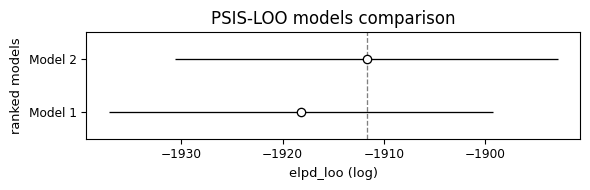

In [25]:
comp_loo = az.compare(comp_dict, ic="loo")
print(comp_loo)

az.plot_compare(comp_loo)
plt.title("PSIS-LOO models comparison")
plt.tight_layout()
plt.show()

The PSIS-LOO results are consistent with WAIC. Model 2 achieves elpd_loo = -432.0 versus Model 1's - 448.0, a difference of 15.98 with dse = 6.62. No Pareto k warnings were issued, indicating that the importance sampling approximation is reliable for all observations in both models and that neither model is driven by a small number of highly influential points.
The ratio elpd_diff/dse ≈ 2.41 again exceeds 2, confirming Model 2 as the preferred model under PSIS-LOO. The near-identical results across both criteria (WAIC and LOO differ by less than 0.1 points) indicate that no outlier observations are distorting the comparison.

### Summary

Both criteria select Model 2 as the better predictive model and the difference is statistically meaningful (elpd_diff/dse $\approx$ 2.4 > 2). Model 2 additional predictors, such as number of ingredients, presence of vanilla, cocoa percantage and review year, provide genuine predictive signal beyond country level effects. This improvement is expected, as 
models with more parameters generally capture more variation in the data.

Model 2 is preffered model when complete chocolate ingredient information is available. However Model 1 also performs well and in our opinion, the practical difference between them is minor. Model 1 remains good alternative, particularly when only geographical information about bean origin and manufacturer is known, as it achieves comparable predictive performance with lower complexity.

## Sources
[1] : [Statista. (2026). Chocolate Confectionery - Worldwide: Market Insights & Forecast. Statista Consumer Market Outlook](https://www.statista.com/outlook/cmo/food/confectionery-snacks/confectionery/chocolate-confectionery/worldwide/?srsltid=AfmBOorxi7XFaZWdLCVjMUYGtJAp6RNSvUAMPQz5kLmDYZJz0M03wTzj)

[2] : [HTF Market Intelligence. (2026). Global Fine or Flavor Cocoa Market: Size, Industry Analysis, Trends, and Forecast to 2033. HTF Market Report.](https://www.htfmarketintelligence.com/report/global-fine-or-flavor-cocoa-market)

[3] : [Grand View Research. (2026). Chocolate Market Size, Share & Trends Analysis Report by Product (Traditional, Artificial), by Distribution Channel, and Segment Forecasts 2026 - 2033. Grand View Research.](https://www.grandviewresearch.com/industry-analysis/chocolate-market)

[4] : [Fanning, E., Eyres, G., Frew, R., & Kebede, B. (2023). Linking cocoa quality attributes to its origin using geographical indications. Food Control, 151, 109825.](https://www.sciencedirect.com/science/article/pii/S0956713523002256)